# 1. Project Setup and Dataset Loading

## 1.1 Objective

In this section, we will set up the Python environment, import the required libraries, and load the Bank Customer Churn dataset.
The goal of this project is to build an Artificial Neural Network (ANN) model that predicts whether a bank customer is likely to churn or not.
The target column for this project is expected to be:

`Exited`

Where:

- `0` means the customer did not churn
- `1` means the customer churned

## 1.2 Set up: Importing libraries and loading dataset

In [62]:
# 1. Import required libraries

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
import tensorflow as tf
import keras_tuner as kt

# Display settings
pd.set_option("display.max_columns", None)

# Check library versions
print("Libraries imported successfully!")
print("-" * 50)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Scikit-learn version:", sklearn.__version__)
print("TensorFlow version:", tf.__version__)
print("KerasTuner version:", kt.__version__)

# 2. Load the dataset

file_path = "Churn Modeling.csv"
df = pd.read_csv(file_path)
df.head()

Libraries imported successfully!
--------------------------------------------------
NumPy version: 1.26.4
Pandas version: 3.0.3
Scikit-learn version: 1.9.0
TensorFlow version: 2.16.2
KerasTuner version: 1.4.8


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# 2. Data Understanding and Basic Cleaning

In this section, we will understand the raw dataset before making any cleaning decisions.
We will check:
- Dataset shape
- Column names
- Data types
- Basic statistical summary
- Missing values
- Duplicate rows
- Target column distribution

At this stage, we are only inspecting the raw dataset. We will not remove or modify any columns yet.

In [63]:
print("Dataset Shape:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\n" + "-" * 60)


print("Column Names:")
print(df.columns.tolist())

print("\n" + "-" * 60)

print("Dataset Info:")
df.info()

print("\n" + "-" * 60)

print("First 5 Rows:")
display(df.head())

print("\n" + "-" * 60)

print("Statistical Summary - Numerical Columns:")
display(df.describe())

print("\n" + "-" * 60)

print("Statistical Summary - Categorical Columns:")
display(df.describe(include="object"))

print("\n" + "-" * 60)

print("Missing Values:")
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage": missing_percentage.round(2)
})

display(missing_summary)

print("\n" + "-" * 60)

duplicate_count = df.duplicated().sum()

print("Duplicate Rows:")
print(f"Number of duplicate rows: {duplicate_count}")

print("\n" + "-" * 60)

print("Target Column Distribution:")
target_counts = df["Exited"].value_counts()
target_percentage = df["Exited"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentage.round(2)
})

display(target_summary)

print("\n" + "-" * 60)

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Dataset Shape:
Rows: 10000
Columns: 14

------------------------------------------------------------
Column Names:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

------------------------------------------------------------
Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



------------------------------------------------------------
Statistical Summary - Numerical Columns:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000



------------------------------------------------------------
Statistical Summary - Categorical Columns:


...


------------------------------------------------------------
Missing Values:


,Missing Count,Missing Percentage
RowNumber,0,0.0
CustomerId,0,0.0
Surname,0,0.0
CreditScore,0,0.0
Geography,0,0.0
Gender,0,0.0
Age,0,0.0
Tenure,0,0.0
Balance,0,0.0
NumOfProducts,0,0.0



------------------------------------------------------------
Duplicate Rows:
Number of duplicate rows: 0

------------------------------------------------------------
Target Column Distribution:


,Count,Percentage
Exited,,
0,7963,79.63
1,2037,20.37



------------------------------------------------------------
Numerical Columns:
['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Categorical Columns:
['Surname', 'Geography', 'Gender']


### Raw dataset understanding - key insights

1. The dataset contains **10,000 customer records** and **14 columns**.

2. The target column is **`Exited`**, which indicates whether a customer churned or not:
   - `0` = Customer did not churn
   - `1` = Customer churned

3. The dataset has **no missing values**, so missing value imputation is not required.

4. The dataset has **no duplicate rows**, so duplicate removal is not required.

5. The target variable is imbalanced:
   - **7,963 customers / 79.63%** did not churn
   - **2,037 customers / 20.37%** churned

   This means accuracy alone may not be enough to evaluate the model. Along with accuracy, we should also check precision, recall, F1-score, confusion matrix, and ROC-AUC.

6. The dataset contains both numerical and categorical features.

   Numerical features include:
   - `CreditScore`
   - `Age`
   - `Tenure`
   - `Balance`
   - `NumOfProducts`
   - `HasCrCard`
   - `IsActiveMember`
   - `EstimatedSalary`

   Categorical features include:
   - `Surname`
   - `Geography`
   - `Gender`

7. The columns `RowNumber`, `CustomerId`, and `Surname` are not useful for prediction:
   - `RowNumber` is only a row index.
   - `CustomerId` is a unique customer identifier.
   - `Surname` is a customer name field with high cardinality.

   These columns should be dropped before model training.

8. The useful categorical columns for prediction are:
   - `Geography`
   - `Gender`

   These will need encoding before building the ANN model.

9. The numerical columns have different value ranges. For example:
   - `CreditScore` ranges from 350 to 850
   - `Age` ranges from 18 to 92
   - `Balance` ranges from 0 to 250,898.09
   - `EstimatedSalary` ranges from 11.58 to 199,992.48

   Because ANN models are sensitive to feature scale, feature scaling will be required before model training.

10. At this stage, the raw dataset is clean enough to proceed with EDA. The main cleaning step needed is to drop non-predictive identifier columns before modeling.

---

# 3. Exploratory data analysis and visualizations

In this section, we will perform visual analysis to understand customer churn patterns.
We will analyze:

- Overall churn distribution
- Churn by geography
- Churn by gender
- Churn by age
- Churn by balance
- Churn by number of products
- Churn by credit card ownership
- Churn by active membership status
- Correlation between numerical variables

For EDA and modeling, we will create a cleaned working copy by removing non-predictive identifier columns:

- `RowNumber`
- `CustomerId`
- `Surname`

In [64]:
df_churn = df.copy()

columns_to_drop = ["RowNumber", "CustomerId", "Surname"]
df_churn = df_churn.drop(columns=columns_to_drop)

print("Original dataset shape:", df.shape)
print("Working dataset shape after dropping identifier columns:", df_churn.shape)

print("\nRemaining columns:")
print(df_churn.columns.tolist())

display(df_churn.head())

Original dataset shape: (10000, 14)
Working dataset shape after dropping identifier columns: (10000, 11)

Remaining columns:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


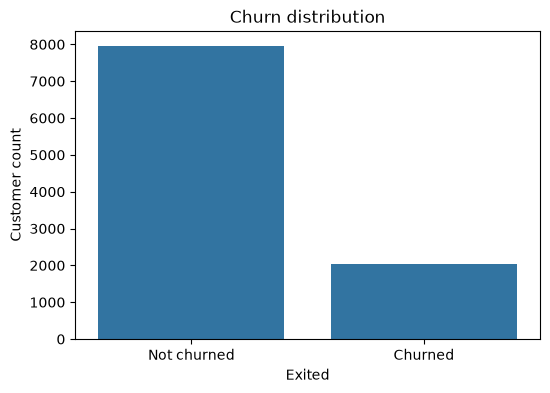

,Exited,Percentage
0,Not churned,79.63
1,Churned,20.37


In [65]:
# 1. Churn distribution

plt.figure(figsize=(6, 4))
sns.countplot(data=df_churn, x="Exited")
plt.title("Churn distribution")
plt.xlabel("Exited")
plt.ylabel("Customer count")
plt.xticks([0, 1], ["Not churned", "Churned"])
plt.show()

# Churn percentage table
churn_summary = df_churn["Exited"].value_counts(normalize=True).mul(100).round(2).reset_index()
churn_summary.columns = ["Exited", "Percentage"]
churn_summary["Exited"] = churn_summary["Exited"].map({0: "Not churned", 1: "Churned"})

display(churn_summary)

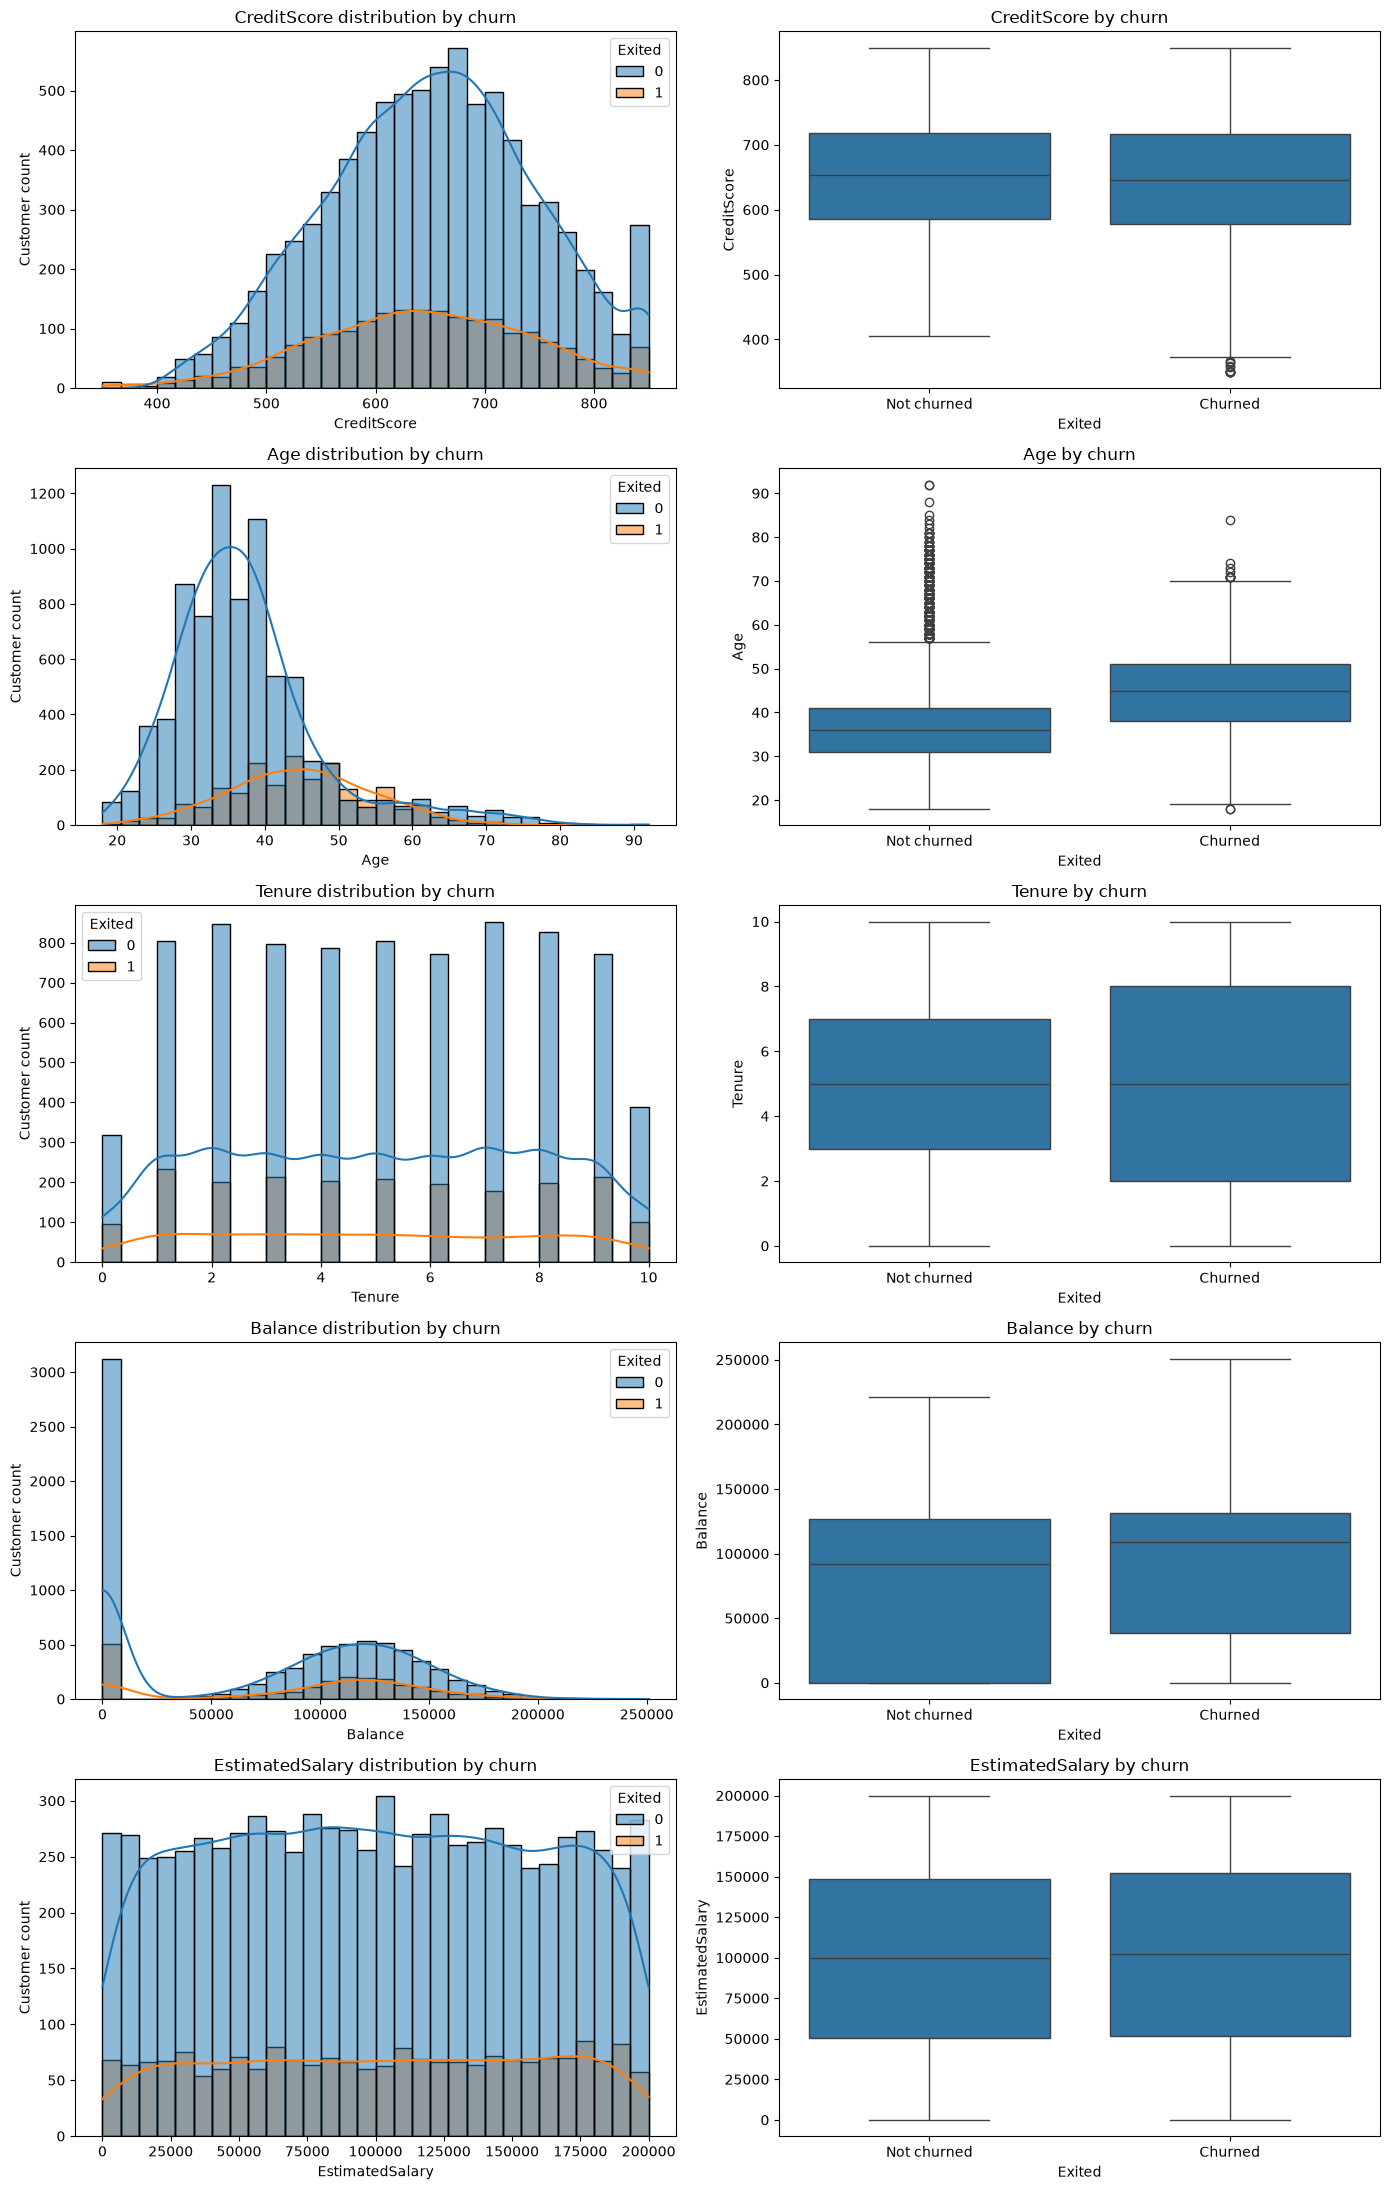

In [66]:
# 2. Numerical feature analysis against churn

numerical_features = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary"]

fig, axes = plt.subplots(
    nrows=len(numerical_features),
    ncols=2,
    figsize=(14, 22)
)

for i, feature in enumerate(numerical_features):
    
    # Histogram/KDE plot
    sns.histplot(
        data=df_churn,
        x=feature,
        hue="Exited",
        kde=True,
        bins=30,
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f"{feature} distribution by churn")
    axes[i, 0].set_xlabel(feature)
    axes[i, 0].set_ylabel("Customer count")
    
    # Boxplot
    sns.boxplot(
        data=df_churn,
        x="Exited",
        y=feature,
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f"{feature} by churn")
    axes[i, 1].set_xlabel("Exited")
    axes[i, 1].set_ylabel(feature)
    axes[i, 1].set_xticklabels(["Not churned", "Churned"])

plt.tight_layout()
plt.show()

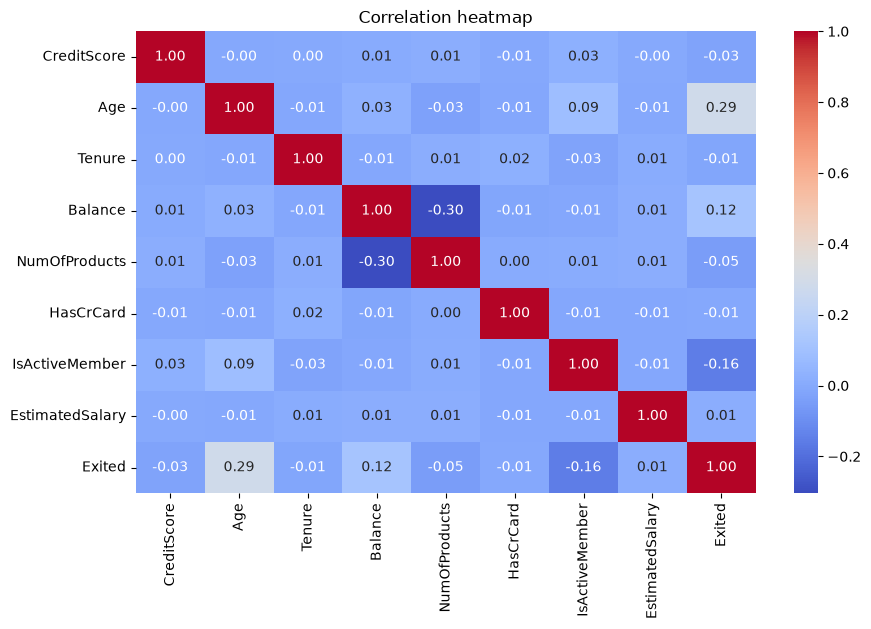

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CreditScore,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097
Exited,-0.027094,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000


In [67]:
# 3. Correlation heatmap for numerical features

plt.figure(figsize=(10, 6))
correlation_matrix = df_churn.corr(numeric_only=True)

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

display(correlation_matrix)

### Exploratory data analysis - key insights

1. The non-predictive identifier columns `RowNumber`, `CustomerId`, and `Surname` were removed from the working dataset.
2. After dropping these columns, the working dataset contains **10,000 rows and 11 columns**.
3. The target variable `Exited` is imbalanced:
   - **79.63%** customers did not churn
   - **20.37%** customers churned
   This means model accuracy alone may be misleading. We should also evaluate precision, recall, F1-score, confusion matrix, and ROC-AUC.

4. `Age` shows the strongest visible relationship with churn among the numerical variables.
   Churned customers appear to be older on average than non-churned customers. The correlation between `Age` and `Exited` is also the strongest positive correlation in the heatmap, around **0.29**.

5. `Balance` also shows some relationship with churn.
   Churned customers appear to have slightly higher account balances compared to non-churned customers. The correlation between `Balance` and `Exited` is around **0.12**, which is positive but not very strong.

6. `IsActiveMember` has a negative relationship with churn.
   The correlation between `IsActiveMember` and `Exited` is around **-0.16**, suggesting that active members are less likely to churn.

7. `CreditScore` does not show a strong relationship with churn.
   The distributions of churned and non-churned customers look quite similar, and the correlation with `Exited` is very weak at around **-0.03**.

8. `Tenure` does not show a strong relationship with churn.
   The churn and non-churn distributions look similar, and the correlation with `Exited` is close to **0**.

9. `EstimatedSalary` does not appear to influence churn strongly.
   The distribution is almost uniform across both churned and non-churned customers, and the correlation with `Exited` is very weak at around **0.01**.

10. The correlation heatmap does not show strong multicollinearity among most input features.
   However, `Balance` and `NumOfProducts` have a moderate negative correlation of around **-0.30**, which is worth noting but not severe enough to remove either feature at this stage.

11. Overall, the most important early signals from the numerical EDA are:
   - `Age`
   - `Balance`
   - `IsActiveMember`

   These may be useful predictors for the ANN model.

   

## Categorical and discrete feature analysis

In this step, we will analyze categorical and discrete features to see how churn varies across customer groups.
We will check churn patterns for:

- `Geography`
- `Gender`
- `NumOfProducts`
- `HasCrCard`
- `IsActiveMember`

For each feature, we will create:
- A countplot showing churn and non-churn customer counts
- A churn rate table showing the percentage of customers who churned in each group

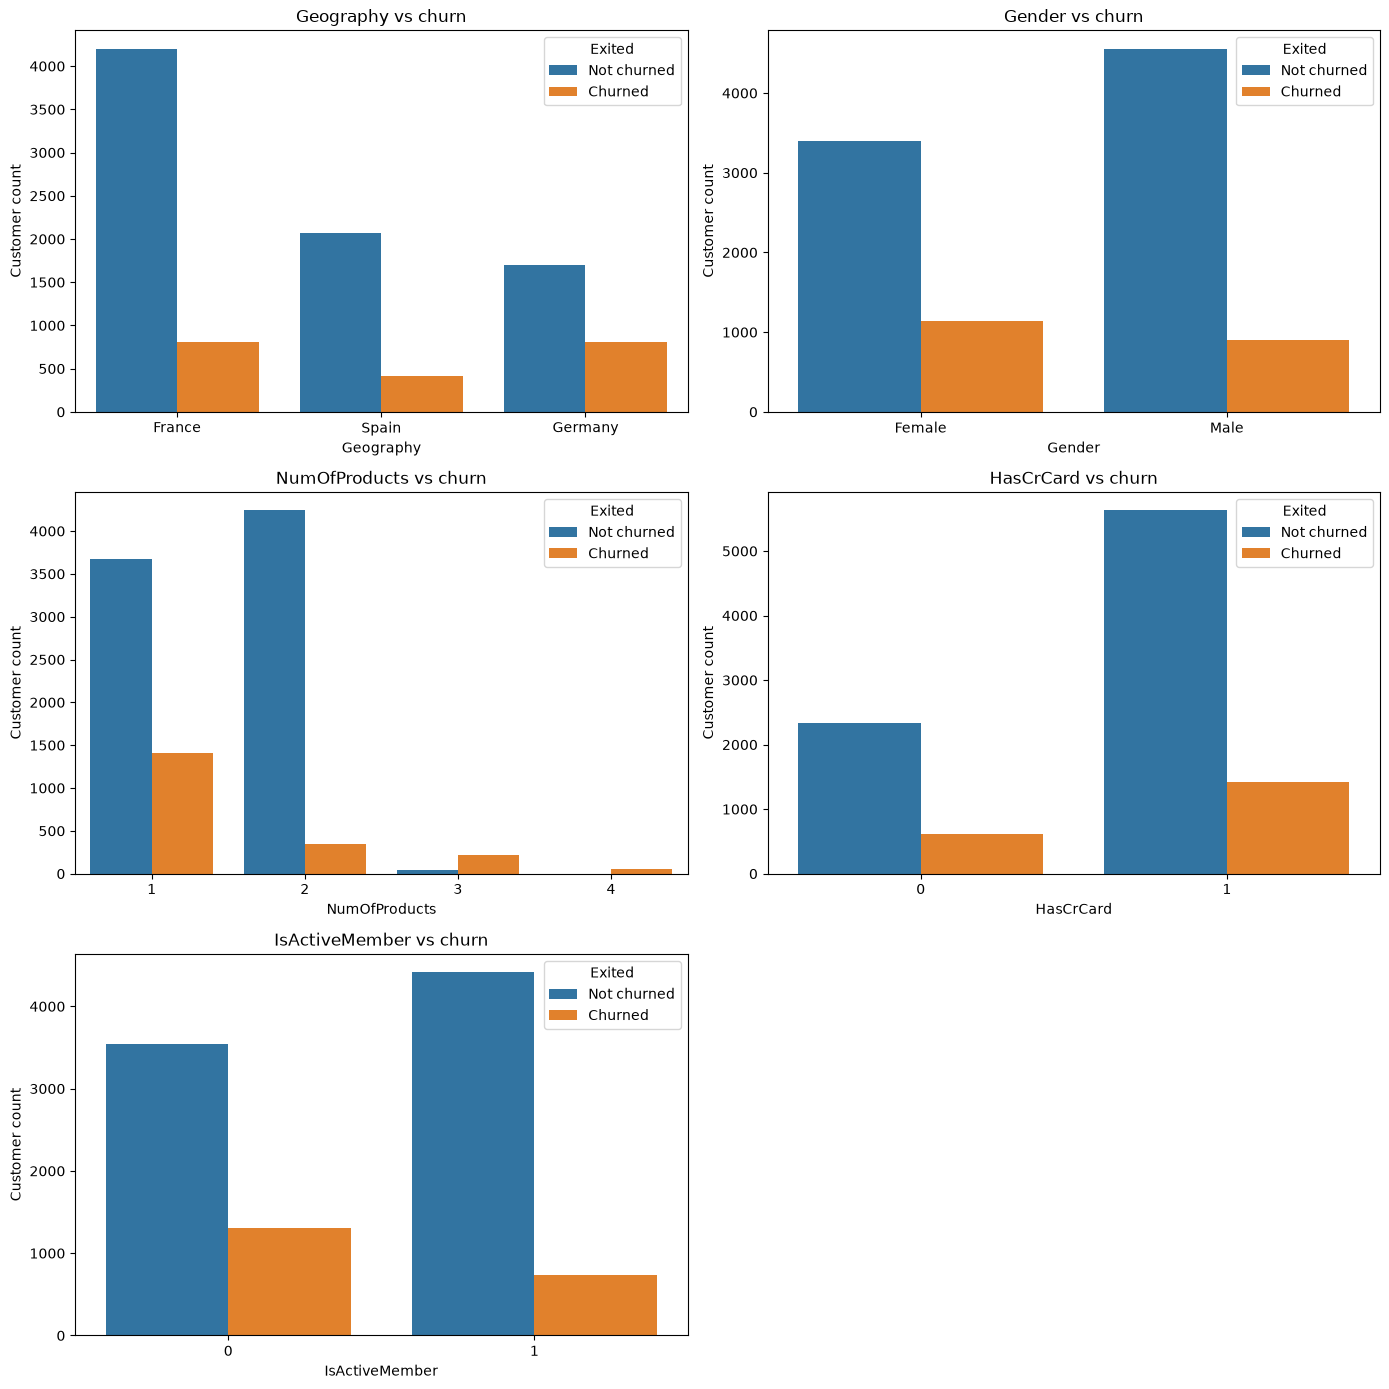


Churn rate by Geography
--------------------------------------------------


,Total customers,Churned customers,Churn rate
Geography,,,
France,5014,810,16.15
Germany,2509,814,32.44
Spain,2477,413,16.67



Churn rate by Gender
--------------------------------------------------


,Total customers,Churned customers,Churn rate
Gender,,,
Female,4543,1139,25.07
Male,5457,898,16.46



Churn rate by NumOfProducts
--------------------------------------------------


,Total customers,Churned customers,Churn rate
NumOfProducts,,,
1,5084,1409,27.71
2,4590,348,7.58
3,266,220,82.71
4,60,60,100.00



Churn rate by HasCrCard
--------------------------------------------------


,Total customers,Churned customers,Churn rate
HasCrCard,,,
0,2945,613,20.81
1,7055,1424,20.18



Churn rate by IsActiveMember
--------------------------------------------------


,Total customers,Churned customers,Churn rate
IsActiveMember,,,
0,4849,1302,26.85
1,5151,735,14.27


In [68]:
# 1. Categorical and discrete feature analysis against churn

categorical_features = ["Geography", "Gender", "NumOfProducts", "HasCrCard", "IsActiveMember"]

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 14)
)

axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.countplot(
        data=df_churn,
        x=feature,
        hue="Exited",
        ax=axes[i]
    )
    
    axes[i].set_title(f"{feature} vs churn")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Customer count")
    axes[i].legend(title="Exited", labels=["Not churned", "Churned"])

# 2. Remove extra empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


# 3. Churn rate tables for categorical/discrete features

for feature in categorical_features:
    print(f"\nChurn rate by {feature}")
    print("-" * 50)
    
    churn_rate_table = (
        df_churn.groupby(feature)["Exited"]
        .agg(["count", "sum", "mean"])
        .rename(columns={
            "count": "Total customers",
            "sum": "Churned customers",
            "mean": "Churn rate"
        })
    )
    
    churn_rate_table["Churn rate"] = (churn_rate_table["Churn rate"] * 100).round(2)
    
    display(churn_rate_table)

### Exploratory data analysis - key insights

1. The non-predictive identifier columns `RowNumber`, `CustomerId`, and `Surname` were removed from the working dataset.

2. After dropping these columns, the working dataset contains **10,000 rows and 11 columns**.

3. The target variable `Exited` is imbalanced:
   - **79.63%** customers did not churn
   - **20.37%** customers churned

   This means accuracy alone may not be enough to evaluate the model. We should also check precision, recall, F1-score, confusion matrix, and ROC-AUC.

4. `Geography` shows a clear churn pattern.

   Germany has the highest churn rate at **32.44%**, while France and Spain have much lower churn rates at **16.15%** and **16.67%** respectively. This suggests that geography may be an important predictor.

5. `Gender` also shows a churn difference.

   Female customers have a higher churn rate of **25.07%**, compared to male customers at **16.46%**.

6. `Age` shows the strongest visible relationship with churn among the numerical variables.

   Churned customers appear to be older on average than non-churned customers. The correlation between `Age` and `Exited` is also the strongest positive correlation in the heatmap, around **0.29**.

7. `Balance` shows a mild positive relationship with churn.

   Churned customers appear to have slightly higher account balances compared to non-churned customers. The correlation between `Balance` and `Exited` is around **0.12**.

8. `NumOfProducts` shows a strong churn pattern.

   Customers with **1 product** have a churn rate of **27.71%**, while customers with **2 products** have a much lower churn rate of **7.58%**.

   Customers with **3 products** have a very high churn rate of **82.71%**, and customers with **4 products** show **100% churn**. However, these groups are much smaller, so this should be interpreted carefully.

9. `IsActiveMember` is an important churn indicator.

   Inactive customers have a churn rate of **26.85%**, while active customers have a much lower churn rate of **14.27%**. This suggests active members are less likely to churn.

10. `HasCrCard` does not show a meaningful churn difference.

   Customers without a credit card have a churn rate of **20.81%**, while customers with a credit card have a churn rate of **20.18%**. This difference is very small.

11. `CreditScore`, `Tenure`, and `EstimatedSalary` do not show strong direct relationships with churn in the EDA.

   Their distributions are broadly similar across churned and non-churned customers, and their correlations with `Exited` are very weak.

12. The correlation heatmap does not show severe multicollinearity among input features.

   `Balance` and `NumOfProducts` have a moderate negative correlation of around **-0.30**, but this is not high enough to remove either feature at this stage.

13. Overall, the strongest early churn signals from EDA are:

   - `Age`
   - `Geography`
   - `Gender`
   - `Balance`
   - `NumOfProducts`
   - `IsActiveMember`

   These features are likely to be useful for ANN model training.

   ----

# 4. Distribution, skewness check, and transformation decision

In this section, we will check the distribution and skewness of numerical features.
The assignment asks us to check whether transformations are required. So we will:
- Plot numerical feature distributions
- Calculate skewness values
- Interpret the skewness level
- Decide whether transformation is required

We will check these numerical features:
- `CreditScore`
- `Age`
- `Tenure`
- `Balance`
- `NumOfProducts`
- `EstimatedSalary`

Binary columns such as `HasCrCard` and `IsActiveMember` will not be checked for skewness transformation because they contain only 0 and 1 values.

For ANN models, feature scaling is usually more important than forcing transformations. Therefore, we will transform a feature only if there is a strong reason to do so.

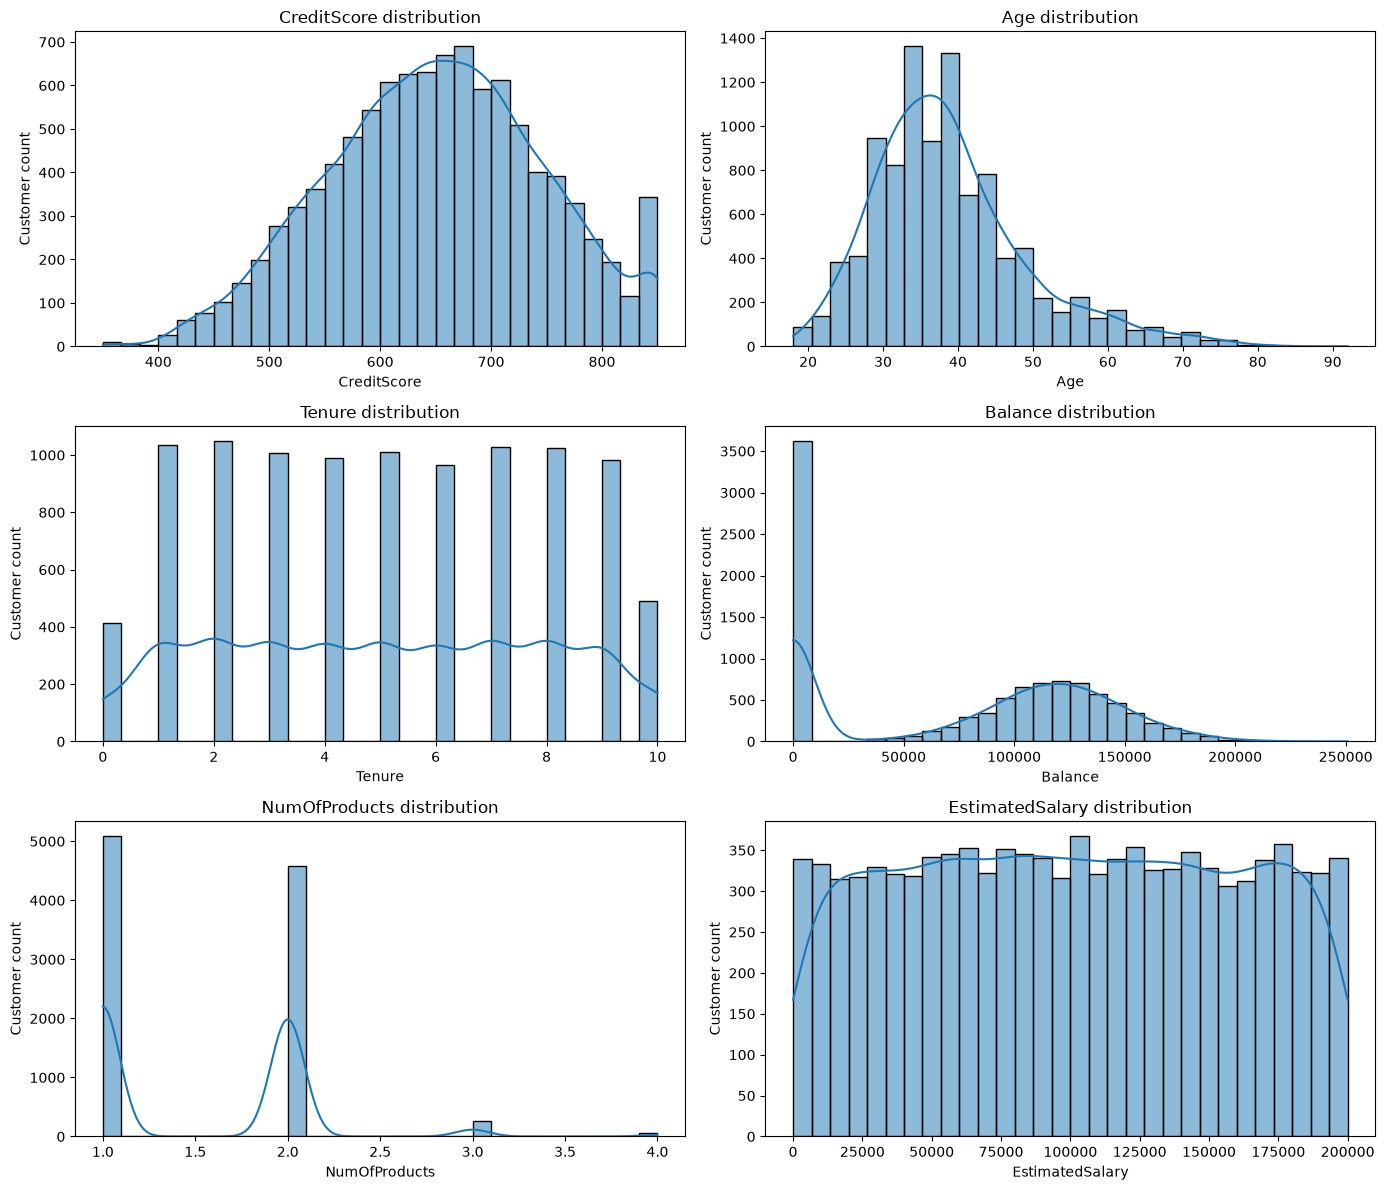

In [69]:
# 1. Distribution plots for numerical features

skewness_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 12)
)

axes = axes.flatten()

for i, feature in enumerate(skewness_features):
    sns.histplot(
        data=df_churn,
        x=feature,
        kde=True,
        bins=30,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{feature} distribution")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Customer count")

plt.tight_layout()
plt.show()

In [70]:
# 2. Calculate skewness for numerical features

skewness_values = df_churn[skewness_features].skew().sort_values(ascending=False)

skewness_summary = pd.DataFrame({
    "Feature": skewness_values.index,
    "Skewness": skewness_values.values
})

def interpret_skewness(value):
    if abs(value) < 0.5:
        return "Almost symmetric"
    elif abs(value) < 1:
        return "Moderately skewed"
    else:
        return "Highly skewed"

skewness_summary["Skewness"] = skewness_summary["Skewness"].round(3)
skewness_summary["Interpretation"] = skewness_summary["Skewness"].apply(interpret_skewness)

display(skewness_summary)

,Feature,Skewness,Interpretation
0,Age,1.011,Highly skewed
1,NumOfProducts,0.746,Moderately skewed
2,Tenure,0.011,Almost symmetric
3,EstimatedSalary,0.002,Almost symmetric
4,CreditScore,-0.072,Almost symmetric
5,Balance,-0.141,Almost symmetric


In [71]:
# 3. Data-driven transformation assessment table

transformation_rows = []

for feature in skewness_features:
    series = df_churn[feature]
    
    skewness_value = series.skew()
    unique_count = series.nunique()
    min_value = series.min()
    max_value = series.max()
    zero_percentage = (series.eq(0).mean() * 100).round(2)
    
    # Feature type detection
    if unique_count <= 10:
        feature_type = "Discrete / low-cardinality numerical"
    else:
        feature_type = "Continuous numerical"
    
    # Skewness interpretation
    if abs(skewness_value) < 0.5:
        skewness_interpretation = "Almost symmetric"
    elif abs(skewness_value) < 1:
        skewness_interpretation = "Moderately skewed"
    else:
        skewness_interpretation = "Highly skewed"
    
    # Direction of skewness
    if skewness_value > 0:
        skew_direction = "Right-skewed"
    elif skewness_value < 0:
        skew_direction = "Left-skewed"
    else:
        skew_direction = "No skew"
    
    # Data-driven transformation recommendation
    if unique_count <= 10:
        transformation_decision = "No transformation recommended"
        reason = "Feature has limited discrete values, so transformation may reduce interpretability."
        
    elif abs(skewness_value) < 0.5:
        transformation_decision = "No transformation required"
        reason = "Skewness is low, so the distribution is close to symmetric."
        
    elif zero_percentage > 20:
        transformation_decision = "No automatic transformation"
        reason = "Feature has many zero values, so transformation should not be applied blindly."
        
    elif abs(skewness_value) >= 1:
        transformation_decision = "No transformation applied"
        reason = "Feature is highly skewed, but no transformation is applied because it is meaningful and StandardScaler will be used before ANN modeling."
        
    else:
        transformation_decision = "Transformation optional"
        reason = "Feature is moderately skewed. For ANN, scaling may be sufficient."
    
    transformation_rows.append({
        "Feature": feature,
        "Feature type": feature_type,
        "Min": min_value,
        "Max": max_value,
        "Unique values": unique_count,
        "Zero %": zero_percentage,
        "Skewness": round(skewness_value, 3),
        "Skew direction": skew_direction,
        "Skewness interpretation": skewness_interpretation,
        "Transformation decision": transformation_decision,
        "Reason": reason
    })

transformation_assessment = pd.DataFrame(transformation_rows)

display(transformation_assessment)

,Feature,Feature type,Min,Max,Unique values,Zero %,Skewness,Skew direction,Skewness interpretation,Transformation decision,Reason
0,CreditScore,Continuous numerical,350.00,850.00,460,0.00,-0.072,Left-skewed,Almost symmetric,No transformation required,"Skewness is low, so the distribution is close ..."
1,Age,Continuous numerical,18.00,92.00,70,0.00,1.011,Right-skewed,Highly skewed,No transformation applied,"Feature is highly skewed, but no transformatio..."
2,Tenure,Continuous numerical,0.00,10.00,11,4.13,0.011,Right-skewed,Almost symmetric,No transformation required,"Skewness is low, so the distribution is close ..."
3,Balance,Continuous numerical,0.00,250898.09,6382,36.17,-0.141,Left-skewed,Almost symmetric,No transformation required,"Skewness is low, so the distribution is close ..."
4,NumOfProducts,Discrete / low-cardinality numerical,1.00,4.00,4,0.00,0.746,Right-skewed,Moderately skewed,No transformation recommended,"Feature has limited discrete values, so transf..."
5,EstimatedSalary,Continuous numerical,11.58,199992.48,9999,0.00,0.002,Right-skewed,Almost symmetric,No transformation required,"Skewness is low, so the distribution is close ..."


### Distribution and skewness - key insights

1. The numerical feature distributions were checked for:

   - `CreditScore`
   - `Age`
   - `Tenure`
   - `Balance`
   - `NumOfProducts`
   - `EstimatedSalary`

2. `Age` has the highest skewness value at **1.011**, which indicates a right-skewed distribution.

   This is expected because most customers are concentrated in younger and middle-age groups, while older customers are fewer.

3. `Age` is right-skewed, with a skewness value of **1.011**, but no transformation will be applied.

   The observed age values are valid, and ANN models do not require input features to follow a normal distribution. The potential benefit of transforming age is therefore not sufficient to justify changing its original scale. `StandardScaler` will be applied later to standardise feature scales, but scaling does not remove or correct skewness.

4. `NumOfProducts` has moderate right skewness with a skewness value of **0.746**.

   However, it is a discrete count feature with only values from 1 to 4, so transformation is not recommended.

5. `CreditScore`, `Tenure`, `Balance`, and `EstimatedSalary` are almost symmetric based on skewness values.

   Their skewness values are close to 0, so no transformation is required.

6. `Balance` contains many zero values, but these are meaningful customer records, not errors.

   A zero balance may represent a valid customer account state, so no automatic transformation will be applied.

7. `EstimatedSalary` is almost uniformly distributed and has very low skewness.

   No transformation is required for this feature.

8. Based on the distribution plots, skewness values, and business meaning of the features, no numerical feature transformation will be applied at this stage.

9. Numerical features will be standardised later using `StandardScaler` because ANN training is sensitive to differences in feature scale. This scaling step changes the centre and spread of the variables but does not correct their distributional skewness.

10. This satisfies the assignment requirement to check distributions/skewness and decide whether transformations are required.

---

# 5. Outlier check and treatment decision

In this section, we will check whether the numerical features contain outliers.
The assignment asks us to check and treat outliers if required. So we will:
- Create boxplots for numerical features
- Calculate outliers using the IQR method
- Count how many outliers are present in each feature
- Check the outlier percentage
- Decide whether treatment is required

We will check these features:
- `CreditScore`
- `Age`
- `Tenure`
- `Balance`
- `NumOfProducts`
- `EstimatedSalary`

Important note:

Outliers in customer churn data are not always errors. For example, older customers, high-balance customers, or customers with more products may be valid business cases. Therefore, we will not remove or cap outliers blindly.

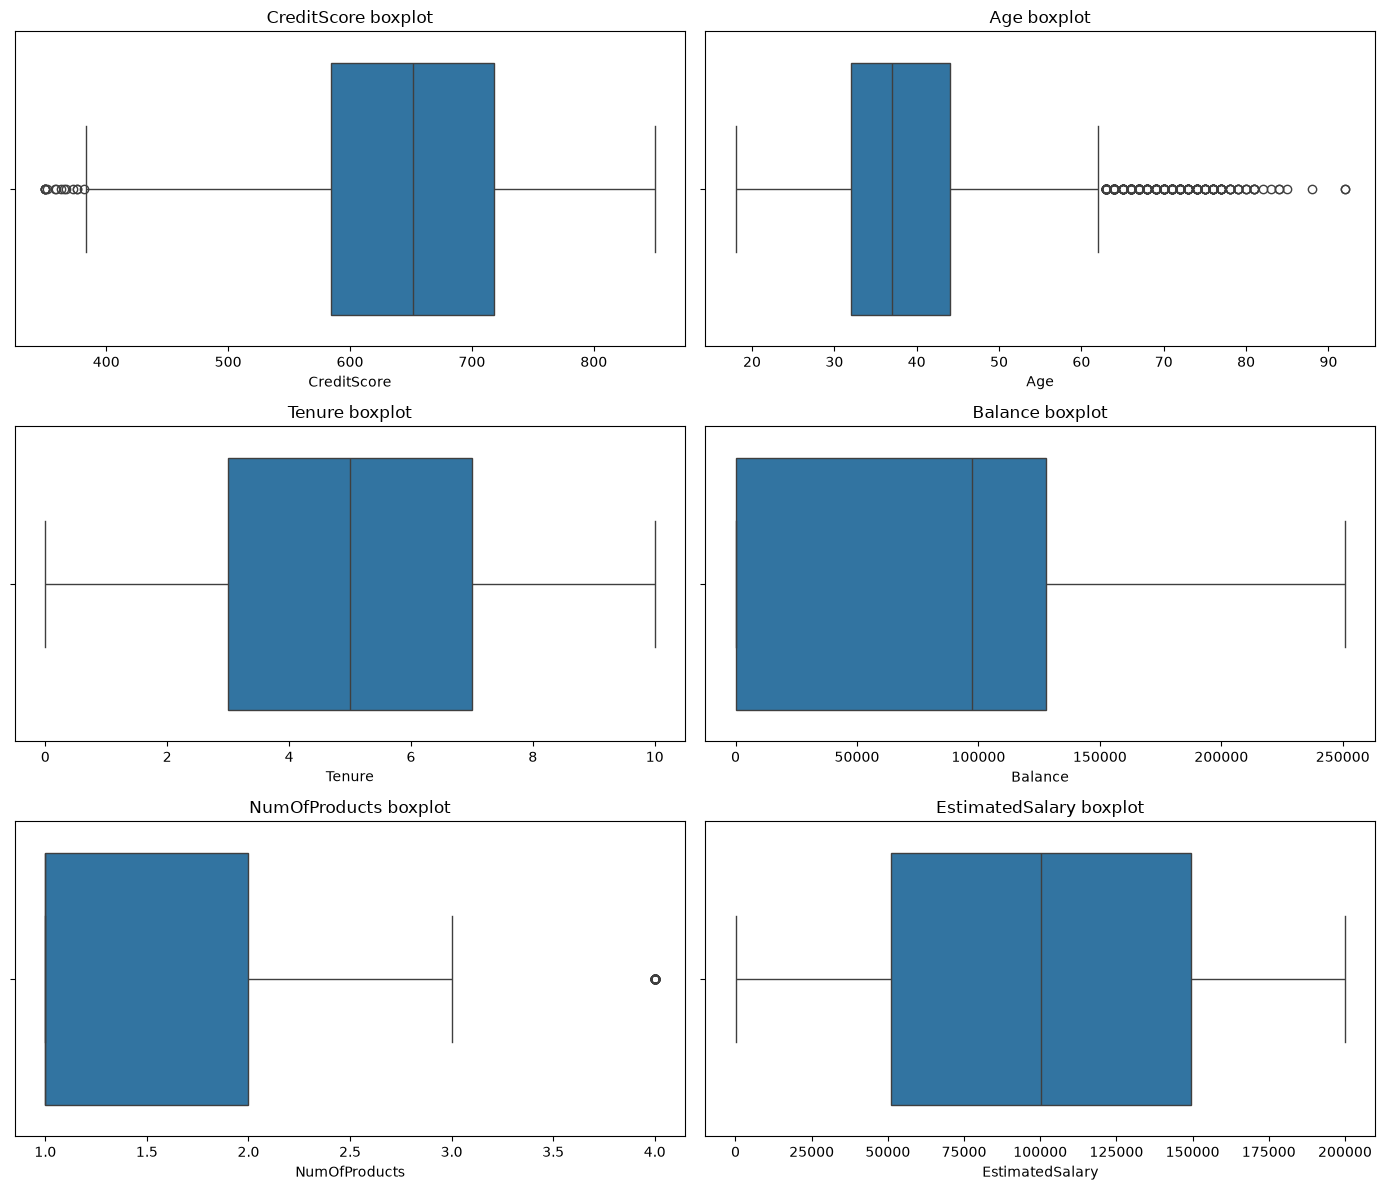

In [72]:
# 1. Boxplots for numerical features

outlier_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 12)
)

axes = axes.flatten()

for i, feature in enumerate(outlier_features):
    sns.boxplot(
        data=df_churn,
        x=feature,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{feature} boxplot")
    axes[i].set_xlabel(feature)

plt.tight_layout()
plt.show()

In [73]:
# 2. IQR-based outlier summary

outlier_summary_rows = []

for feature in outlier_features:
    Q1 = df_churn[feature].quantile(0.25)
    Q3 = df_churn[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_mask = (
        (df_churn[feature] < lower_bound) |
        (df_churn[feature] > upper_bound)
    )
    
    outlier_count = outlier_mask.sum()
    outlier_percentage = (outlier_count / len(df_churn)) * 100
    
    outlier_summary_rows.append({
        "Feature": feature,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Lower bound": round(lower_bound, 2),
        "Upper bound": round(upper_bound, 2),
        "Min": df_churn[feature].min(),
        "Max": df_churn[feature].max(),
        "Outlier count": outlier_count,
        "Outlier percentage": round(outlier_percentage, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary_rows)

display(outlier_summary)

,Feature,Q1,Q3,IQR,Lower bound,Upper bound,Min,Max,Outlier count,Outlier percentage
0,CreditScore,584.00,718.00,134.00,383.00,919.00,350.00,850.00,15,0.15
1,Age,32.00,44.00,12.00,14.00,62.00,18.00,92.00,359,3.59
2,Tenure,3.00,7.00,4.00,-3.00,13.00,0.00,10.00,0,0.00
3,Balance,0.00,127644.24,127644.24,-191466.36,319110.60,0.00,250898.09,0,0.00
4,NumOfProducts,1.00,2.00,1.00,-0.50,3.50,1.00,4.00,60,0.60
5,EstimatedSalary,51002.11,149388.25,98386.14,-96577.10,296967.45,11.58,199992.48,0,0.00


In [74]:
# 3. Outlier treatment assessment

outlier_treatment_rows = []

for feature in outlier_features:
    row = outlier_summary[outlier_summary["Feature"] == feature].iloc[0]
    
    unique_count = df_churn[feature].nunique()
    outlier_count = row["Outlier count"]
    outlier_percentage = row["Outlier percentage"]
    
    # 3.1 Identify feature type
    if unique_count <= 15:
        feature_type = "Discrete / bounded numerical"
    else:
        feature_type = "Continuous numerical"
    
    # 3.2 Data-driven treatment recommendation
    if outlier_count == 0:
        treatment_decision = "No treatment required"
        reason = "No IQR outliers were detected."
        
    elif unique_count <= 15:
        treatment_decision = "Keep outliers"
        reason = "Feature has limited valid values, so IQR may flag valid categories as outliers."
        
    elif outlier_percentage < 1:
        treatment_decision = "Keep outliers"
        reason = "Outlier percentage is very low, and these values can represent valid customer records."
        
    elif outlier_percentage <= 5:
        treatment_decision = "Keep for now"
        reason = "Outliers are present but may represent valid customer behavior."
        
    else:
        treatment_decision = "Further investigation needed"
        reason = "Outlier percentage is relatively high and should be checked before treatment."
    
    outlier_treatment_rows.append({
        "Feature": feature,
        "Feature type": feature_type,
        "Unique values": unique_count,
        "Outlier count": outlier_count,
        "Outlier percentage": outlier_percentage,
        "Treatment decision": treatment_decision,
        "Reason": reason
    })

outlier_treatment_assessment = pd.DataFrame(outlier_treatment_rows)

display(outlier_treatment_assessment)

,Feature,Feature type,Unique values,Outlier count,Outlier percentage,Treatment decision,Reason
0,CreditScore,Continuous numerical,460,15,0.15,Keep outliers,"Outlier percentage is very low, and these valu..."
1,Age,Continuous numerical,70,359,3.59,Keep for now,Outliers are present but may represent valid c...
2,Tenure,Discrete / bounded numerical,11,0,0.00,No treatment required,No IQR outliers were detected.
3,Balance,Continuous numerical,6382,0,0.00,No treatment required,No IQR outliers were detected.
4,NumOfProducts,Discrete / bounded numerical,4,60,0.60,Keep outliers,"Feature has limited valid values, so IQR may f..."
5,EstimatedSalary,Continuous numerical,9999,0,0.00,No treatment required,No IQR outliers were detected.


### Outlier check and treatment - key insights

1. Outliers were checked using boxplots and the IQR method for:

   - `CreditScore`
   - `Age`
   - `Tenure`
   - `Balance`
   - `NumOfProducts`
   - `EstimatedSalary`

2. `CreditScore` has **15 outliers**, which is only **0.15%** of the dataset.

   These are very low credit score values below the IQR lower bound. Since the percentage is very small and low credit scores can be valid customer records, no removal or capping will be applied.

3. `Age` has **359 outliers**, which is **3.59%** of the dataset.

   These are mainly older customers above the IQR upper bound of **62 years**. Since older customers are valid bank customers and age is an important churn signal, these records will be kept.

4. `NumOfProducts` has **60 outliers**, which is **0.60%** of the dataset.

   This happens because the IQR upper bound is **3.5**, so customers with **4 products** are flagged as outliers. However, `NumOfProducts` is a valid discrete count feature, so these records will be kept.

5. `Tenure`, `Balance`, and `EstimatedSalary` have **no IQR outliers**.

   No outlier treatment is required for these features.

6. No outliers will be removed or capped at this stage.

   Reason: the detected outliers appear to represent valid customer behavior rather than data errors.

7. This satisfies the assignment requirement to check and treat outliers if required.

   Since no invalid or extreme erroneous values were found, the final treatment decision is to retain the outliers and proceed with feature scaling in the next section.

   ---

# 6. Preprocessing, encoding, train-test split, and feature scaling

In this section, the dataset will be prepared for ANN model development.

The following steps will be performed:

- Separate the input features and target
- Split the data into 80% development data and 20% final test data
- Use stratified splitting because the target variable is imbalanced
- Encode categorical features using `OneHotEncoder`
- Scale numerical features using `StandardScaler`
- Keep binary features in their validated 0/1 form
- Fit preprocessing only on training data to prevent data leakage

The target column is:

`Exited`

The 20% test set will be reserved for final evaluation and must not be used for ANN architecture selection, early stopping, KerasTuner, threshold selection or final-model selection.

In Step 7, the 80% development data will be divided into model-training and validation subsets. A fresh preprocessor will be fitted only on the model-training subset for the ANN comparison.

In [75]:
# 1. Define features and target

target_column = "Exited"

X = df_churn.drop(columns=[target_column])
y = df_churn[target_column]

print("Feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget distribution:")

target_distribution = pd.DataFrame({
    "Class": y.value_counts().index,
    "Count": y.value_counts().values,
    "Percentage": y.value_counts(normalize=True).mul(100).round(2).values
})

target_distribution["Class"] = target_distribution["Class"].map({
    0: "Not churned",
    1: "Churned"
})

display(target_distribution)

Feature dataset shape: (10000, 10)
Target dataset shape: (10000,)

Feature columns:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Target distribution:


,Class,Count,Percentage
0,Not churned,7963,79.63
1,Churned,2037,20.37


In [76]:
# 2. Define feature groups

categorical_features = ["Geography", "Gender"]

numerical_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

binary_features = [
    "HasCrCard",
    "IsActiveMember"
]

expected_features = categorical_features + numerical_features + binary_features

missing_features = [col for col in expected_features if col not in X.columns]

if len(missing_features) == 0:
    print("All expected features are present.")
else:
    print("Missing features found:", missing_features)

print("\nCategorical features:", categorical_features)
print("Numerical features:", numerical_features)
print("Binary features:", binary_features)

All expected features are present.

Categorical features: ['Geography', 'Gender']
Numerical features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
Binary features: ['HasCrCard', 'IsActiveMember']


In [77]:
# 3. Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution:")

train_distribution = pd.DataFrame({
    "Class": y_train.value_counts().index,
    "Count": y_train.value_counts().values,
    "Percentage": y_train.value_counts(normalize=True).mul(100).round(2).values
})

train_distribution["Class"] = train_distribution["Class"].map({
    0: "Not churned",
    1: "Churned"
})

display(train_distribution)

print("\nTesting target distribution:")

test_distribution = pd.DataFrame({
    "Class": y_test.value_counts().index,
    "Count": y_test.value_counts().values,
    "Percentage": y_test.value_counts(normalize=True).mul(100).round(2).values
})

test_distribution["Class"] = test_distribution["Class"].map({
    0: "Not churned",
    1: "Churned"
})

display(test_distribution)

X_train shape: (8000, 10)
X_test shape: (2000, 10)
y_train shape: (8000,)
y_test shape: (2000,)

Training target distribution:


,Class,Count,Percentage
0,Not churned,6370,79.62
1,Churned,1630,20.38



Testing target distribution:


,Class,Count,Percentage
0,Not churned,1593,79.65
1,Churned,407,20.35


In [78]:
# 4. Preprocessing: encoding categorical features and scaling numerical features

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("bin", "passthrough", binary_features)
    ],
    remainder="drop"
)

# Fit only on training data to avoid data leakage
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

# Convert to float32 for TensorFlow/Keras compatibility
X_train_processed = X_train_processed.astype("float32")
X_test_processed = X_test_processed.astype("float32")

y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

print("Preprocessing completed successfully!")
print("-" * 50)
print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("\nData type of processed training data:", X_train_processed.dtype)

Preprocessing completed successfully!
--------------------------------------------------
X_train_processed shape: (8000, 13)
X_test_processed shape: (2000, 13)
y_train shape: (8000,)
y_test shape: (2000,)

Data type of processed training data: float32


### Preprocessing, encoding, train-test split, and feature scaling — key insights

1. The final feature dataset contains **10 input features** after removing the target column `Exited`.

2. The target variable `Exited` was separated successfully:

   - `0` = Not churned
   - `1` = Churned

3. The dataset was divided using a stratified **80:20 split**:

   - Development data: **8,000 records**
   - Final test data: **2,000 records**

4. Stratification preserved the churn ratio in both partitions:

   - Development-data churn rate: **20.38%**
   - Final-test churn rate: **20.35%**

5. Categorical features were encoded using `OneHotEncoder`:

   - `Geography`
   - `Gender`

6. Numerical features were scaled using `StandardScaler` because ANN training is sensitive to differences in feature scale.

7. Binary features were retained as validated 0/1 values:

   - `HasCrCard`
   - `IsActiveMember`

8. The Step 6 preprocessor was fitted only on the 80% development partition and applied to the final test partition without refitting.

9. After one-hot encoding, the number of model inputs increased from **10 raw features to 13 processed features**.

10. The processed feature arrays were converted to `float32` for TensorFlow/Keras compatibility.

11. The final test partition must remain excluded from ANN architecture selection, early stopping, hyperparameter tuning, threshold selection and final-model selection.

12. In Step 7, the development partition will be divided into model-training and validation subsets, and a fresh preprocessor will be fitted only on the model-training subset.

----

# 7. Basic ANN model with multiple hidden layers

In this section, a Basic Artificial Neural Network will be built as the baseline model.

The model will use:

- An input layer based on the processed feature count
- Multiple Dense hidden layers
- ReLU activation in the hidden layers
- Sigmoid activation in the output layer
- Binary crossentropy loss
- Adam optimiser
- Accuracy, precision, recall and ROC-AUC as Keras training metrics

The Basic ANN will be trained using the model-training partition and monitored using the validation partition.

During model development, performance will be evaluated only on:

- Training data
- Validation data

The final test set will not be evaluated during this step.

The post-training evaluation will include:

- Accuracy
- Balanced accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC using Average Precision
- Log loss
- Validation classification report
- Validation confusion matrix

Dropout, EarlyStopping and ModelCheckpoint will be introduced in the next step.

In [79]:
# 1. Create clean modeling train-validation split before preprocessing

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X_model_train_raw, X_model_val_raw, y_model_train, y_model_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train.astype(int)
)

model_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("bin", "passthrough", binary_features)
    ],
    remainder="drop"
)

X_model_train_processed = model_preprocessor.fit_transform(X_model_train_raw)
X_model_val_processed = model_preprocessor.transform(X_model_val_raw)
X_test_model_processed = model_preprocessor.transform(X_test)

X_model_train_processed = X_model_train_processed.astype("float32")
X_model_val_processed = X_model_val_processed.astype("float32")
X_test_model_processed = X_test_model_processed.astype("float32")

y_model_train = y_model_train.astype("float32")
y_model_val = y_model_val.astype("float32")
y_test_model = y_test.astype("float32")

print("Model training data shape:", X_model_train_processed.shape)
print("Model validation data shape:", X_model_val_processed.shape)
print("Model test data shape:", X_test_model_processed.shape)

print("Model training target shape:", y_model_train.shape)
print("Model validation target shape:", y_model_val.shape)
print("Model test target shape:", y_test_model.shape)

print("\nTraining churn distribution:")
display(
    pd.DataFrame({
        "Class": pd.Series(y_model_train).value_counts().index,
        "Count": pd.Series(y_model_train).value_counts().values,
        "Percentage": pd.Series(y_model_train).value_counts(normalize=True).mul(100).round(2).values
    }).replace({"Class": {0.0: "Not churned", 1.0: "Churned"}})
)

print("\nValidation churn distribution:")
display(
    pd.DataFrame({
        "Class": pd.Series(y_model_val).value_counts().index,
        "Count": pd.Series(y_model_val).value_counts().values,
        "Percentage": pd.Series(y_model_val).value_counts(normalize=True).mul(100).round(2).values
    }).replace({"Class": {0.0: "Not churned", 1.0: "Churned"}})
)

print("\nTest churn distribution:")
display(
    pd.DataFrame({
        "Class": pd.Series(y_test_model).value_counts().index,
        "Count": pd.Series(y_test_model).value_counts().values,
        "Percentage": pd.Series(y_test_model).value_counts(normalize=True).mul(100).round(2).values
    }).replace({"Class": {0.0: "Not churned", 1.0: "Churned"}})
)

Model training data shape: (6400, 13)
Model validation data shape: (1600, 13)
Model test data shape: (2000, 13)
Model training target shape: (6400,)
Model validation target shape: (1600,)
Model test target shape: (2000,)

Training churn distribution:


,Class,Count,Percentage
0,Not churned,5096,79.62
1,Churned,1304,20.38



Validation churn distribution:


,Class,Count,Percentage
0,Not churned,1274,79.62
1,Churned,326,20.38



Test churn distribution:


,Class,Count,Percentage
0,Not churned,1593,79.65
1,Churned,407,20.35


In [80]:
# 2. Build and compile the basic ANN model

import random
import tensorflow as tf

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

input_dim = X_model_train_processed.shape[1]

basic_ann_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    
    tf.keras.layers.Dense(1, activation="sigmoid")
])

basic_ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

basic_ann_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
# 3. Train the basic ANN model

history_basic_ann = basic_ann_model.fit(
    X_model_train_processed,
    y_model_train,
    validation_data=(X_model_val_processed, y_model_val),
    epochs=50,
    batch_size=32,
    verbose=1,
    shuffle=True
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8073 - auc: 0.7245 - loss: 0.4535 - precision: 0.6821 - recall: 0.1020 - val_accuracy: 0.8238 - val_auc: 0.7995 - val_loss: 0.4055 - val_precision: 0.7750 - val_recall: 0.1902
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8417 - auc: 0.8321 - loss: 0.3743 - precision: 0.7381 - recall: 0.3459 - val_accuracy: 0.8519 - val_auc: 0.8396 - val_loss: 0.3674 - val_precision: 0.7514 - val_recall: 0.4080
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8539 - auc: 0.8506 - loss: 0.3528 - precision: 0.7393 - recall: 0.4371 - val_accuracy: 0.8569 - val_auc: 0.8480 - val_loss: 0.3575 - val_precision: 0.7622 - val_recall: 0.4325
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8550 - auc: 0.8578 - loss: 0.3445 - precision: 0.7380 - recall: 0.4471 - val_accuracy: 0.8531 - val_auc: 0.8502 - val_loss: 0.3547 - val_precision: 0.7382 - val_recall: 0.4325
Epoch 5/50
200/200 ━━━━━━━━━━━━━

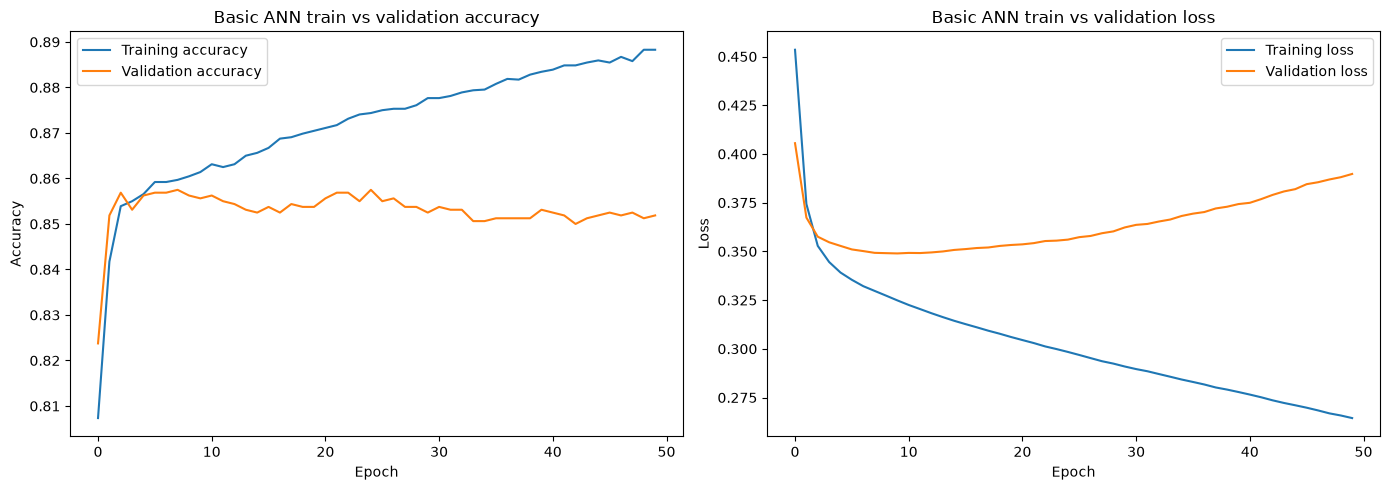

In [82]:
# 4. Plot training and validation performance

history_basic_df = pd.DataFrame(history_basic_ann.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history_basic_df["accuracy"], label="Training accuracy")
axes[0].plot(history_basic_df["val_accuracy"], label="Validation accuracy")
axes[0].set_title("Basic ANN train vs validation accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Loss plot
axes[1].plot(history_basic_df["loss"], label="Training loss")
axes[1].plot(history_basic_df["val_loss"], label="Validation loss")
axes[1].set_title("Basic ANN train vs validation loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

Basic ANN training-validation results:


,Dataset,Accuracy,Balanced accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC (Average Precision),Loss
0,Training,0.8894,0.7793,0.8130,0.5936,0.6862,0.9239,0.8118,0.2599
1,Validation,0.8519,0.7061,0.7109,0.4601,0.5587,0.8399,0.6500,0.3897



Classification report on validation data:
              precision    recall  f1-score   support

 Not churned       0.87      0.95      0.91      1274
     Churned       0.71      0.46      0.56       326

    accuracy                           0.85      1600
   macro avg       0.79      0.71      0.73      1600
weighted avg       0.84      0.85      0.84      1600



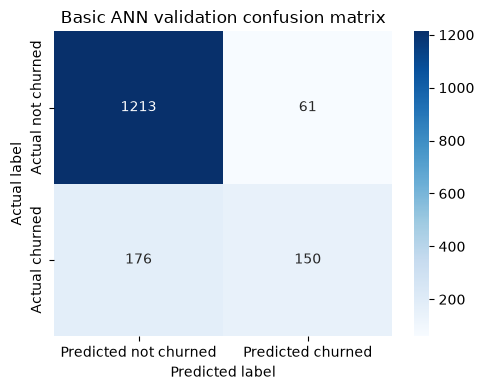

In [83]:
# 5. Evaluate the Basic ANN on training and validation data only

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    log_loss
)


def evaluate_ann_model(
    model,
    X_data,
    y_true,
    dataset_name,
    threshold=0.50
):
    y_true_int = np.asarray(y_true).astype(int)

    y_pred_proba = model.predict(
        X_data,
        verbose=0
    ).ravel()

    y_pred = (
        y_pred_proba >= threshold
    ).astype(int)

    return {
        "Dataset": dataset_name,

        "Accuracy": round(
            accuracy_score(
                y_true_int,
                y_pred
            ),
            4
        ),

        "Balanced accuracy": round(
            balanced_accuracy_score(
                y_true_int,
                y_pred
            ),
            4
        ),

        "Precision": round(
            precision_score(
                y_true_int,
                y_pred,
                zero_division=0
            ),
            4
        ),

        "Recall": round(
            recall_score(
                y_true_int,
                y_pred,
                zero_division=0
            ),
            4
        ),

        "F1-score": round(
            f1_score(
                y_true_int,
                y_pred,
                zero_division=0
            ),
            4
        ),

        "ROC-AUC": round(
            roc_auc_score(
                y_true_int,
                y_pred_proba
            ),
            4
        ),

        "PR-AUC (Average Precision)": round(
            average_precision_score(
                y_true_int,
                y_pred_proba
            ),
            4
        ),

        "Loss": round(
            log_loss(
                y_true_int,
                y_pred_proba
            ),
            4
        )
    }


basic_train_results = evaluate_ann_model(
    model=basic_ann_model,
    X_data=X_model_train_processed,
    y_true=y_model_train,
    dataset_name="Training"
)

basic_val_results = evaluate_ann_model(
    model=basic_ann_model,
    X_data=X_model_val_processed,
    y_true=y_model_val,
    dataset_name="Validation"
)

basic_ann_metrics_df = pd.DataFrame([
    basic_train_results,
    basic_val_results
])

print("Basic ANN training-validation results:")
display(basic_ann_metrics_df)


# Validation predictions

y_val_pred_proba_basic = basic_ann_model.predict(
    X_model_val_processed,
    verbose=0
).ravel()

y_val_pred_basic = (
    y_val_pred_proba_basic >= 0.50
).astype(int)

y_val_int = np.asarray(
    y_model_val
).astype(int)


# Validation classification report

print("\nClassification report on validation data:")

print(
    classification_report(
        y_val_int,
        y_val_pred_basic,
        target_names=[
            "Not churned",
            "Churned"
        ],
        zero_division=0
    )
)


# Validation confusion matrix

cm_basic_validation = confusion_matrix(
    y_val_int,
    y_val_pred_basic
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_basic_validation,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted not churned",
        "Predicted churned"
    ],
    yticklabels=[
        "Actual not churned",
        "Actual churned"
    ]
)

plt.title(
    "Basic ANN validation confusion matrix"
)

plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.tight_layout()
plt.show()

In [84]:
# 6. Store the Basic ANN validation result for later comparison

basic_ann_comparison_result = {
    "Model": "Basic ANN",
    "Threshold": 0.50,

    "Train accuracy":
        basic_train_results["Accuracy"],

    "Validation accuracy":
        basic_val_results["Accuracy"],

    "Train balanced accuracy":
        basic_train_results["Balanced accuracy"],

    "Validation balanced accuracy":
        basic_val_results["Balanced accuracy"],

    "Train precision":
        basic_train_results["Precision"],

    "Validation precision":
        basic_val_results["Precision"],

    "Train recall":
        basic_train_results["Recall"],

    "Validation recall":
        basic_val_results["Recall"],

    "Train F1-score":
        basic_train_results["F1-score"],

    "Validation F1-score":
        basic_val_results["F1-score"],

    "Train ROC-AUC":
        basic_train_results["ROC-AUC"],

    "Validation ROC-AUC":
        basic_val_results["ROC-AUC"],

    "Train PR-AUC":
        basic_train_results[
            "PR-AUC (Average Precision)"
        ],

    "Validation PR-AUC":
        basic_val_results[
            "PR-AUC (Average Precision)"
        ],

    "Train loss":
        basic_train_results["Loss"],

    "Validation loss":
        basic_val_results["Loss"]
}


if "model_results" not in globals():
    model_results = []


model_results = [
    result
    for result in model_results
    if result.get("Model") != "Basic ANN"
]

model_results.append(
    basic_ann_comparison_result
)

model_comparison_df = pd.DataFrame(
    model_results
)

display(model_comparison_df)

,Model,Threshold,Train accuracy,Validation accuracy,Train balanced accuracy,Validation balanced accuracy,Train precision,Validation precision,Train recall,Validation recall,Train F1-score,Validation F1-score,Train ROC-AUC,Validation ROC-AUC,Train PR-AUC,Validation PR-AUC,Train loss,Validation loss
0,"Improved ANN with Dropout, EarlyStopping, and ...",0.5,0.8703,0.8625,0.7325,0.7174,0.7855,0.7624,0.5000,0.4724,0.6111,0.5833,0.8801,0.8602,0.7313,0.6920,0.3175,0.3423
1,Tuned ANN using KerasTuner,0.5,0.8572,0.8538,0.6883,0.6742,0.7946,0.8067,0.4034,0.3712,0.5351,0.5084,0.8620,0.8554,0.6925,0.6804,0.3505,0.3612
2,Class-weighted Improved ANN,0.5,0.8128,0.7987,0.7980,0.7789,0.5277,0.5041,0.7730,0.7454,0.6273,0.6015,0.8894,0.8578,0.7399,0.6842,0.3948,0.4266
3,Class-weighted Improved ANN with tuned threshold,0.6,0.8506,0.8375,0.7858,0.7610,0.6229,0.5954,0.6764,0.6319,0.6485,0.6131,0.8894,0.8578,0.7399,0.6842,0.3948,0.4266
4,Improved ANN with tuned threshold,0.3,0.8509,0.8462,0.7740,0.7654,0.6316,0.6212,0.6442,0.6288,0.6378,0.6250,0.8801,0.8602,0.7313,0.6920,0.3175,0.3423
5,Basic ANN,0.5,0.8894,0.8519,0.7793,0.7061,0.8130,0.7109,0.5936,0.4601,0.6862,0.5587,0.9239,0.8399,0.8118,0.6500,0.2599,0.3897


### Basic ANN model — key insights

1. The Basic ANN achieved **88.94% training accuracy** and **85.19% validation accuracy**, giving an accuracy gap of approximately **3.75 percentage points**.

2. Validation ROC-AUC was **0.8399**, showing that the model has reasonably good ability to rank churned customers above non-churned customers.

3. Validation PR-AUC, measured using Average Precision, was **0.6500**, which is substantially higher than the churn prevalence and indicates useful minority-class ranking performance.

4. At the default classification threshold of **0.50**, churn precision was **71.09%**, meaning that most customers predicted as churned were correctly classified.

5. Churn recall was only **46.01%**. The model correctly identified **150 of 326** churned customers but missed **176**, showing that the baseline model remains biased towards the majority non-churn class.

6. Validation balanced accuracy was **70.61%**, which is considerably lower than the overall accuracy of **85.19%** and confirms that accuracy alone overstates the model's performance across both classes.

7. Training performance was consistently higher than validation performance, including F1-score (**0.6862 vs 0.5587**) and ROC-AUC (**0.9239 vs 0.8399**), indicating some overfitting.

8. The Basic ANN provides a valid baseline, but its limited churn recall and training-validation gap justify testing dropout regularisation, EarlyStopping and ModelCheckpoint in the next step.

---

# 8. ANN improvement using Dropout, EarlyStopping, and ModelCheckpoint

In this section, the Basic ANN will be improved using regularisation and training callbacks.

The Improved ANN will use:

- `Dropout` to reduce overfitting
- `EarlyStopping` to stop training when validation loss stops improving
- `ModelCheckpoint` to save model weights after every epoch
- A separate `ModelCheckpoint` to save the best complete model

The same deterministic training-validation split used for the Basic ANN will be recreated using the same source data, stratification and random seed.

A fresh preprocessor will be fitted only on the raw modelling-training subset. The fitted preprocessor will then be applied to the validation and test partitions without refitting.

The saved best-model checkpoint will be explicitly reloaded before evaluation.

During this step, the Improved ANN will be evaluated only on:

- Training data
- Validation data

The test set will not be evaluated or used for model comparison during model development.

The same threshold and evaluation metrics used for the Basic ANN will be used to ensure a fair comparison.

In [85]:
# 1. Create clean raw train-validation split before preprocessing

from sklearn.model_selection import train_test_split

X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train.astype(int)
)

print("Raw training data shape:", X_train_raw.shape)
print("Raw validation data shape:", X_val_raw.shape)
print("Raw training target shape:", y_train_raw.shape)
print("Raw validation target shape:", y_val_raw.shape)

print("\nRaw training target distribution:")
train_raw_distribution = pd.DataFrame({
    "Class": pd.Series(y_train_raw).value_counts().index,
    "Count": pd.Series(y_train_raw).value_counts().values,
    "Percentage": pd.Series(y_train_raw).value_counts(normalize=True).mul(100).round(2).values
})

train_raw_distribution["Class"] = train_raw_distribution["Class"].map({
    0: "Not churned",
    1: "Churned"
})

display(train_raw_distribution)

print("\nRaw validation target distribution:")
val_raw_distribution = pd.DataFrame({
    "Class": pd.Series(y_val_raw).value_counts().index,
    "Count": pd.Series(y_val_raw).value_counts().values,
    "Percentage": pd.Series(y_val_raw).value_counts(normalize=True).mul(100).round(2).values
})

val_raw_distribution["Class"] = val_raw_distribution["Class"].map({
    0: "Not churned",
    1: "Churned"
})

display(val_raw_distribution)

Raw training data shape: (6400, 10)
Raw validation data shape: (1600, 10)
Raw training target shape: (6400,)
Raw validation target shape: (1600,)

Raw training target distribution:


,Class,Count,Percentage
0,Not churned,5096,79.62
1,Churned,1304,20.38



Raw validation target distribution:


,Class,Count,Percentage
0,Not churned,1274,79.62
1,Churned,326,20.38


In [86]:
# 2. Fit a fresh preprocessor only on the raw training subset

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor_improved = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("bin", "passthrough", binary_features)
    ],
    remainder="drop"
)

# Fit only on raw training subset
X_train_improved = preprocessor_improved.fit_transform(X_train_raw)

# Transform validation and test data using the fitted preprocessor
X_val_improved = preprocessor_improved.transform(X_val_raw)
X_test_improved = preprocessor_improved.transform(X_test)

# Convert to float32 for TensorFlow/Keras
X_train_improved = X_train_improved.astype("float32")
X_val_improved = X_val_improved.astype("float32")
X_test_improved = X_test_improved.astype("float32")

y_train_improved = y_train_raw.astype("float32")
y_val_improved = y_val_raw.astype("float32")
y_test_improved = y_test.astype("float32")

print("Improved preprocessing completed successfully!")
print("-" * 60)
print("X_train_improved shape:", X_train_improved.shape)
print("X_val_improved shape:", X_val_improved.shape)
print("X_test_improved shape:", X_test_improved.shape)
print("y_train_improved shape:", y_train_improved.shape)
print("y_val_improved shape:", y_val_improved.shape)
print("y_test_improved shape:", y_test_improved.shape)
print("\nData type:", X_train_improved.dtype)

Improved preprocessing completed successfully!
------------------------------------------------------------
X_train_improved shape: (6400, 13)
X_val_improved shape: (1600, 13)
X_test_improved shape: (2000, 13)
y_train_improved shape: (6400,)
y_val_improved shape: (1600,)
y_test_improved shape: (2000,)

Data type: float32


In [87]:
# 3. Build improved ANN model with Dropout

import random
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

input_dim_improved = X_train_improved.shape[1]

improved_ann_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim_improved,)),
    
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.30),
    
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.20),
    
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dropout(0.10),
    
    tf.keras.layers.Dense(1, activation="sigmoid")
])

improved_ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

improved_ann_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
# 4. Define EarlyStopping and ModelCheckpoint callbacks

import os
import glob

os.makedirs("checkpoints", exist_ok=True)
os.makedirs("models", exist_ok=True)

# Remove old improved ANN checkpoint files if this section is rerun
old_checkpoint_files = glob.glob("checkpoints/improved_ann_epoch_*.weights.h5")

for file in old_checkpoint_files:
    os.remove(file)

old_best_model_file = "models/best_improved_ann_model.keras"

if os.path.exists(old_best_model_file):
    os.remove(old_best_model_file)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

# Saves model weights after every epoch to satisfy the assignment requirement
checkpoint_each_epoch = tf.keras.callbacks.ModelCheckpoint(
    filepath="checkpoints/improved_ann_epoch_{epoch:02d}.weights.h5",
    monitor="val_loss",
    save_best_only=False,
    save_weights_only=True,
    verbose=0
)

# Saves the best full model separately
best_model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="models/best_improved_ann_model.keras",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

callbacks_improved = [
    early_stopping,
    checkpoint_each_epoch,
    best_model_checkpoint
]

print("Callbacks created successfully.")

Callbacks created successfully.


In [89]:
# 5. Train improved ANN model

history_improved_ann = improved_ann_model.fit(
    X_train_improved,
    y_train_improved,
    validation_data=(X_val_improved, y_val_improved),
    epochs=100,
    batch_size=32,
    callbacks=callbacks_improved,
    verbose=1,
    shuffle=True
)

Epoch 1/100
173/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7585 - auc: 0.6100 - loss: 0.5221 - precision: 0.2222 - recall: 0.0724
Epoch 1: val_loss improved from None to 0.43336, saving model to models/best_improved_ann_model.keras

Epoch 1: finished saving model to models/best_improved_ann_model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7641 - auc: 0.6256 - loss: 0.5118 - precision: 0.2246 - recall: 0.0644 - val_accuracy: 0.7962 - val_auc: 0.7663 - val_loss: 0.4334 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/100
185/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8035 - auc: 0.7541 - loss: 0.4415 - precision: 0.6062 - recall: 0.0972    
Epoch 2: val_loss improved from 0.43336 to 0.40987, saving model to models/best_improved_ann_model.keras

Epoch 2: finished saving model to models/best_improved_ann_model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8045 - auc: 0.7579 - loss: 0.4391 - precision: 0.6233 - recall: 0.1028 - va

In [90]:
# 6. Check saved checkpoint files

epoch_checkpoint_files = sorted(glob.glob("checkpoints/improved_ann_epoch_*.weights.h5"))
best_model_file = "models/best_improved_ann_model.keras"

print("Number of epoch checkpoint files saved:", len(epoch_checkpoint_files))

if len(epoch_checkpoint_files) > 0:
    print("\nFirst few checkpoint files:")
    print(epoch_checkpoint_files[:3])
    
    print("\nLast few checkpoint files:")
    print(epoch_checkpoint_files[-3:])

print("\nBest model file exists:", os.path.exists(best_model_file))

Number of epoch checkpoint files saved: 33

First few checkpoint files:
['checkpoints/improved_ann_epoch_01.weights.h5', 'checkpoints/improved_ann_epoch_02.weights.h5', 'checkpoints/improved_ann_epoch_03.weights.h5']

Last few checkpoint files:
['checkpoints/improved_ann_epoch_31.weights.h5', 'checkpoints/improved_ann_epoch_32.weights.h5', 'checkpoints/improved_ann_epoch_33.weights.h5']

Best model file exists: True


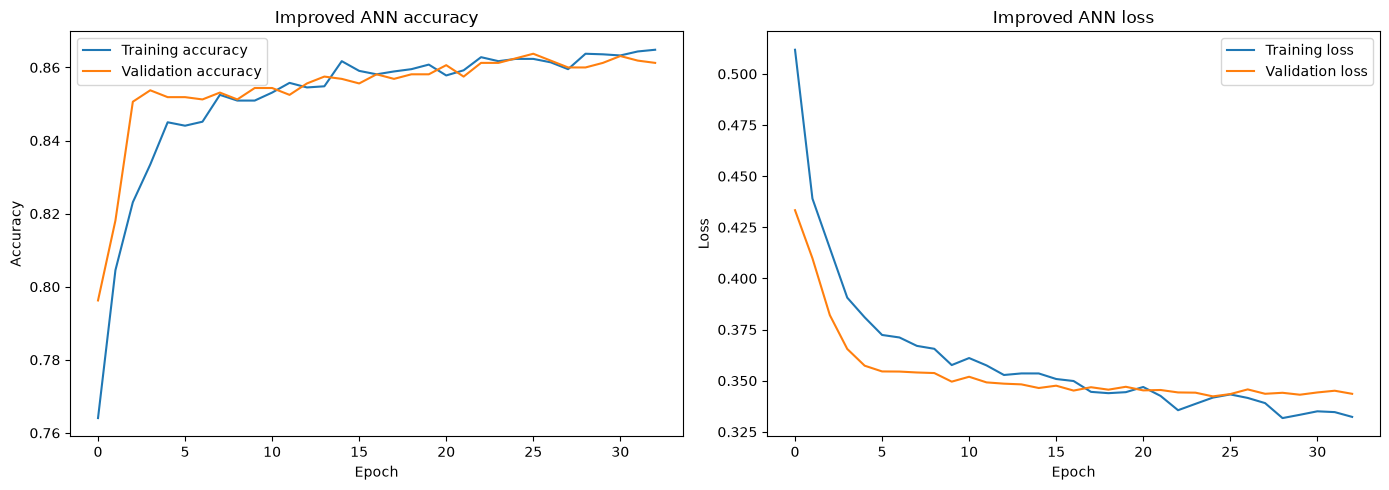

In [91]:
# 7. Plot improved ANN training and validation performance

history_improved_df = pd.DataFrame(history_improved_ann.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_improved_df["accuracy"], label="Training accuracy")
axes[0].plot(history_improved_df["val_accuracy"], label="Validation accuracy")
axes[0].set_title("Improved ANN accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history_improved_df["loss"], label="Training loss")
axes[1].plot(history_improved_df["val_loss"], label="Validation loss")
axes[1].set_title("Improved ANN loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

Best Improved ANN checkpoint reloaded successfully.

Improved ANN training-validation results:


,Dataset,Accuracy,Balanced accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC (Average Precision),Loss
0,Training,0.8703,0.7325,0.7855,0.5000,0.6111,0.8801,0.7313,0.3175
1,Validation,0.8625,0.7174,0.7624,0.4724,0.5833,0.8602,0.6920,0.3423



Classification report on validation data:
              precision    recall  f1-score   support

 Not churned       0.88      0.96      0.92      1274
     Churned       0.76      0.47      0.58       326

    accuracy                           0.86      1600
   macro avg       0.82      0.72      0.75      1600
weighted avg       0.85      0.86      0.85      1600



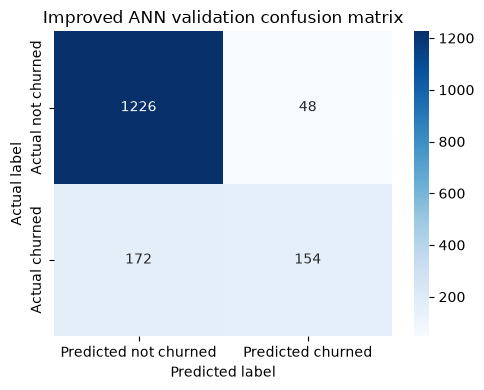

In [92]:
# 8. Reload and evaluate the best Improved ANN checkpoint on training and validation data only

improved_ann_model = tf.keras.models.load_model(
    best_model_file
)

print(
    "Best Improved ANN checkpoint reloaded successfully."
)

improved_train_results = evaluate_ann_model(
    model=improved_ann_model,
    X_data=X_train_improved,
    y_true=y_train_improved,
    dataset_name="Training",
    threshold=0.50
)

improved_val_results = evaluate_ann_model(
    model=improved_ann_model,
    X_data=X_val_improved,
    y_true=y_val_improved,
    dataset_name="Validation",
    threshold=0.50
)


improved_ann_metrics_df = pd.DataFrame([
    improved_train_results,
    improved_val_results
])

print(
    "\nImproved ANN training-validation results:"
)

display(improved_ann_metrics_df)


y_val_pred_proba_improved = improved_ann_model.predict(
    X_val_improved,
    verbose=0
).ravel()

y_val_pred_improved = (
    y_val_pred_proba_improved >= 0.50
).astype(int)

y_val_improved_int = np.asarray(
    y_val_improved
).astype(int)



print(
    "\nClassification report on validation data:"
)

print(
    classification_report(
        y_val_improved_int,
        y_val_pred_improved,
        target_names=[
            "Not churned",
            "Churned"
        ],
        zero_division=0
    )
)


cm_improved_validation = confusion_matrix(
    y_val_improved_int,
    y_val_pred_improved
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_improved_validation,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted not churned",
        "Predicted churned"
    ],
    yticklabels=[
        "Actual not churned",
        "Actual churned"
    ]
)

plt.title(
    "Improved ANN validation confusion matrix"
)

plt.xlabel("Predicted label")
plt.ylabel("Actual label")

plt.tight_layout()
plt.show()

In [93]:
# 9. Store the Improved ANN result for later comparison

improved_ann_comparison_result = {
    "Model": (
        "Improved ANN with Dropout, EarlyStopping, "
        "and ModelCheckpoint"
    ),

    "Threshold": 0.50,

    "Train accuracy":
        improved_train_results["Accuracy"],

    "Validation accuracy":
        improved_val_results["Accuracy"],

    "Train balanced accuracy":
        improved_train_results[
            "Balanced accuracy"
        ],

    "Validation balanced accuracy":
        improved_val_results[
            "Balanced accuracy"
        ],

    "Train precision":
        improved_train_results["Precision"],

    "Validation precision":
        improved_val_results["Precision"],

    "Train recall":
        improved_train_results["Recall"],

    "Validation recall":
        improved_val_results["Recall"],

    "Train F1-score":
        improved_train_results["F1-score"],

    "Validation F1-score":
        improved_val_results["F1-score"],

    "Train ROC-AUC":
        improved_train_results["ROC-AUC"],

    "Validation ROC-AUC":
        improved_val_results["ROC-AUC"],

    "Train PR-AUC":
        improved_train_results[
            "PR-AUC (Average Precision)"
        ],

    "Validation PR-AUC":
        improved_val_results[
            "PR-AUC (Average Precision)"
        ],

    "Train loss":
        improved_train_results["Loss"],

    "Validation loss":
        improved_val_results["Loss"]
}


if "model_results" not in globals():
    model_results = []


model_results = [
    result
    for result in model_results
    if result.get("Model") != (
        "Improved ANN with Dropout, EarlyStopping, "
        "and ModelCheckpoint"
    )
]


model_results.append(
    improved_ann_comparison_result
)


model_comparison_df = pd.DataFrame(
    model_results
)

display(model_comparison_df)

,Model,Threshold,Train accuracy,Validation accuracy,Train balanced accuracy,Validation balanced accuracy,Train precision,Validation precision,Train recall,Validation recall,Train F1-score,Validation F1-score,Train ROC-AUC,Validation ROC-AUC,Train PR-AUC,Validation PR-AUC,Train loss,Validation loss
0,Tuned ANN using KerasTuner,0.5,0.8572,0.8538,0.6883,0.6742,0.7946,0.8067,0.4034,0.3712,0.5351,0.5084,0.8620,0.8554,0.6925,0.6804,0.3505,0.3612
1,Class-weighted Improved ANN,0.5,0.8128,0.7987,0.7980,0.7789,0.5277,0.5041,0.7730,0.7454,0.6273,0.6015,0.8894,0.8578,0.7399,0.6842,0.3948,0.4266
2,Class-weighted Improved ANN with tuned threshold,0.6,0.8506,0.8375,0.7858,0.7610,0.6229,0.5954,0.6764,0.6319,0.6485,0.6131,0.8894,0.8578,0.7399,0.6842,0.3948,0.4266
3,Improved ANN with tuned threshold,0.3,0.8509,0.8462,0.7740,0.7654,0.6316,0.6212,0.6442,0.6288,0.6378,0.6250,0.8801,0.8602,0.7313,0.6920,0.3175,0.3423
4,Basic ANN,0.5,0.8894,0.8519,0.7793,0.7061,0.8130,0.7109,0.5936,0.4601,0.6862,0.5587,0.9239,0.8399,0.8118,0.6500,0.2599,0.3897
5,"Improved ANN with Dropout, EarlyStopping, and ...",0.5,0.8703,0.8625,0.7325,0.7174,0.7855,0.7624,0.5000,0.4724,0.6111,0.5833,0.8801,0.8602,0.7313,0.6920,0.3175,0.3423


### ANN improvement using Dropout, EarlyStopping, and ModelCheckpoint — key insights

1. The Improved ANN used Dropout regularisation, EarlyStopping and ModelCheckpoint while retaining the same modelling-training and validation partitions used for the Basic ANN.

2. The preprocessing object was fitted only on the modelling-training data and then applied to the validation data, preventing preprocessing leakage.

3. ModelCheckpoint stored model weights after every epoch and separately saved the best complete model. The best saved checkpoint was explicitly reloaded before evaluation.

4. The Improved ANN achieved **87.03% training accuracy** and **86.25% validation accuracy**, producing a small accuracy gap of **0.78 percentage points**.

5. Validation balanced accuracy was **71.74%**, compared with overall validation accuracy of **86.25%**. This difference confirms that class imbalance still affects the model’s performance.

6. At the default threshold of **0.50**, validation churn precision was **76.24%** and churn recall was **47.24%**.

7. The validation confusion matrix shows:

   - True negatives: **1,226**
   - False positives: **48**
   - False negatives: **172**
   - True positives: **154**

8. The model correctly identified **154 of 326 churned customers** but missed **172**, meaning that slightly more than half of the actual churn cases were not detected.

9. Compared with the Basic ANN, the Improved ANN increased validation:

   - Accuracy from **0.8519 to 0.8625**
   - Balanced accuracy from **0.7061 to 0.7174**
   - Precision from **0.7109 to 0.7624**
   - Recall from **0.4601 to 0.4724**
   - F1-score from **0.5587 to 0.5833**
   - ROC-AUC from **0.8399 to 0.8602**
   - PR-AUC from **0.6500 to 0.6920**

10. Validation loss decreased from **0.3897** for the Basic ANN to **0.3423** for the Improved ANN.

11. The training-validation gaps also reduced substantially. For example, the F1-score gap decreased from **0.1275** in the Basic ANN to **0.0278** in the Improved ANN, indicating better generalisation and reduced overfitting.

12. The Improved ANN currently performs better than the Basic ANN on all reported validation metrics, but it should not yet be finalised because churn recall remains below 50%.

13. The next step is to use KerasTuner and compare the tuned ANN against both existing models using the same validation data.



----

# 9. Hyperparameter tuning using KerasTuner

In this section, KerasTuner RandomSearch will be used to tune the ANN architecture and training configuration.

The following hyperparameters will be tuned:

- Number of hidden layers
- Number of neurons in each hidden layer
- Hidden-layer activation functions
- Dropout rates
- Optimiser
- Learning rate
- Batch size

The loss function will remain fixed as `binary_crossentropy` because the target is binary and the output layer uses sigmoid activation.

Because the churn target is imbalanced, the tuner will optimise validation PR-AUC (`val_pr_auc`) rather than validation accuracy.

A fixed tuner seed will be used to make the sampled hyperparameter combinations reproducible.

The tuner will use only the fixed modelling-training and validation partitions. The test set will not be evaluated or used for hyperparameter selection.

After tuning, the selected hyperparameters will be used to train a fresh tuned ANN. The best complete model checkpoint will then be explicitly reloaded before training and validation evaluation.

In [94]:
# 1. Import KerasTuner and prepare tuning setup

import keras_tuner as kt
import tensorflow as tf
import random
import os

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

tf.keras.backend.clear_session()

input_dim_tuned = X_train_improved.shape[1]

print("Input dimension for tuned ANN:", input_dim_tuned)
print("Training data shape:", X_train_improved.shape)
print("Validation data shape:", X_val_improved.shape)
print("Test data shape:", X_test_improved.shape)

Input dimension for tuned ANN: 13
Training data shape: (6400, 13)
Validation data shape: (1600, 13)
Test data shape: (2000, 13)


In [95]:
# 2. Define tunable ANN hypermodel

class BankChurnHyperModel(kt.HyperModel):

    def build(self, hp):
        model = tf.keras.Sequential()

        model.add(
            tf.keras.layers.Input(
                shape=(input_dim_tuned,)
            )
        )

        # Tune the number of hidden layers
        num_hidden_layers = hp.Int(
            "num_hidden_layers",
            min_value=1,
            max_value=4,
            step=1
        )

        for layer_index in range(num_hidden_layers):

            units = hp.Int(
                f"units_layer_{layer_index + 1}",
                min_value=16,
                max_value=128,
                step=16
            )

            activation = hp.Choice(
                f"activation_layer_{layer_index + 1}",
                values=["relu", "tanh"]
            )

            dropout_rate = hp.Float(
                f"dropout_rate_{layer_index + 1}",
                min_value=0.0,
                max_value=0.5,
                step=0.1
            )

            model.add(
                tf.keras.layers.Dense(
                    units,
                    activation=activation
                )
            )

            if dropout_rate > 0:
                model.add(
                    tf.keras.layers.Dropout(
                        dropout_rate
                    )
                )

        model.add(
            tf.keras.layers.Dense(
                1,
                activation="sigmoid"
            )
        )

        optimizer_name = hp.Choice(
            "optimizer",
            values=["adam", "rmsprop"]
        )

        learning_rate = hp.Choice(
            "learning_rate",
            values=[
                0.01,
                0.001,
                0.0005,
                0.0001
            ]
        )

        if optimizer_name == "adam":
            optimizer = tf.keras.optimizers.Adam(
                learning_rate=learning_rate
            )
        else:
            optimizer = tf.keras.optimizers.RMSprop(
                learning_rate=learning_rate
            )

        model.compile(
            optimizer=optimizer,
            loss="binary_crossentropy",
            metrics=[
                "accuracy",

                tf.keras.metrics.Precision(
                    name="precision"
                ),

                tf.keras.metrics.Recall(
                    name="recall"
                ),

                tf.keras.metrics.AUC(
                    name="roc_auc"
                ),

                tf.keras.metrics.AUC(
                    curve="PR",
                    name="pr_auc"
                )
            ]
        )

        return model

    def fit(
        self,
        hp,
        model,
        *args,
        **kwargs
    ):
        batch_size = hp.Choice(
            "batch_size",
            values=[16, 32, 64]
        )

        return model.fit(
            *args,
            batch_size=batch_size,
            **kwargs
        )


tuned_hypermodel = BankChurnHyperModel()

In [96]:
# 3. Create KerasTuner RandomSearch object

tuner = kt.RandomSearch(
    hypermodel=tuned_hypermodel,

    objective=kt.Objective(
        "val_pr_auc",
        direction="max"
    ),

    max_trials=8,
    executions_per_trial=1,

    directory="tuner_results",
    project_name="bank_churn_ann_tuning",

    overwrite=True,
    seed=42
)

tuner.search_space_summary()

Search space summary
Default search space size: 6
num_hidden_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_layer_1 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 128, 'step': 16, 'sampling': 'linear'}
activation_layer_1 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh'], 'ordered': False}
dropout_rate_1 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop'], 'ordered': False}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0005, 0.0001], 'ordered': True}


In [97]:
# 4. Run hyperparameter search

tuner_early_stopping = (
    tf.keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1
    )
)

tuner.search(
    X_train_improved,
    y_train_improved,

    validation_data=(
        X_val_improved,
        y_val_improved
    ),

    epochs=50,

    callbacks=[
        tuner_early_stopping
    ],

    verbose=1
)

print("\nCompleted tuner search space:")
tuner.search_space_summary()

Trial 8 Complete [00h 00m 36s]
val_pr_auc: 0.6713047027587891

Best val_pr_auc So Far: 0.6889197826385498
Total elapsed time: 00h 03m 34s

Completed tuner search space:
Search space summary
Default search space size: 16
num_hidden_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_layer_1 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 128, 'step': 16, 'sampling': 'linear'}
activation_layer_1 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh'], 'ordered': False}
dropout_rate_1 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop'], 'ordered': False}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0005, 0.0001], 'ordered': True}
units_layer_2 (Int)
{'default': None, 'conditions': [], 'min_value

In [98]:
# 5. View best hyperparameters

best_hps = tuner.get_best_hyperparameters(
    num_trials=1
)[0]

best_num_layers = best_hps.get(
    "num_hidden_layers"
)

best_batch_size = int(
    best_hps.get("batch_size")
)

best_hyperparameter_rows = [
    {
        "Hyperparameter": "num_hidden_layers",
        "Value": best_num_layers,
        "Tuning status": "Tuned"
    },
    {
        "Hyperparameter": "optimizer",
        "Value": best_hps.get("optimizer"),
        "Tuning status": "Tuned"
    },
    {
        "Hyperparameter": "learning_rate",
        "Value": best_hps.get("learning_rate"),
        "Tuning status": "Tuned"
    },
    {
        "Hyperparameter": "batch_size",
        "Value": best_batch_size,
        "Tuning status": "Tuned"
    },
    {
        "Hyperparameter": "loss_function",
        "Value": "binary_crossentropy",
        "Tuning status": (
            "Fixed - appropriate for binary classification"
        )
    }
]

for layer_index in range(best_num_layers):

    best_hyperparameter_rows.append({
        "Hyperparameter": (
            f"units_layer_{layer_index + 1}"
        ),
        "Value": best_hps.get(
            f"units_layer_{layer_index + 1}"
        ),
        "Tuning status": "Tuned"
    })

    best_hyperparameter_rows.append({
        "Hyperparameter": (
            f"activation_layer_{layer_index + 1}"
        ),
        "Value": best_hps.get(
            f"activation_layer_{layer_index + 1}"
        ),
        "Tuning status": "Tuned"
    })

    best_hyperparameter_rows.append({
        "Hyperparameter": (
            f"dropout_rate_{layer_index + 1}"
        ),
        "Value": best_hps.get(
            f"dropout_rate_{layer_index + 1}"
        ),
        "Tuning status": "Tuned"
    })

best_hyperparameters_df = pd.DataFrame(
    best_hyperparameter_rows
)

display(best_hyperparameters_df)

,Hyperparameter,Value,Tuning status
0,num_hidden_layers,4,Tuned
1,optimizer,adam,Tuned
2,learning_rate,0.01,Tuned
3,batch_size,64,Tuned
4,loss_function,binary_crossentropy,Fixed - appropriate for binary classification
5,units_layer_1,128,Tuned
6,activation_layer_1,tanh,Tuned
7,dropout_rate_1,0.3,Tuned
8,units_layer_2,48,Tuned
9,activation_layer_2,tanh,Tuned


In [99]:
# 6. Build and train the best tuned ANN model

tf.keras.backend.clear_session()

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

best_tuned_ann_model = tuned_hypermodel.build(
    best_hps
)

best_tuned_model_file = (
    "models/best_tuned_ann_model.keras"
)

if os.path.exists(best_tuned_model_file):
    os.remove(best_tuned_model_file)

tuned_early_stopping = (
    tf.keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1
    )
)

tuned_model_checkpoint = (
    tf.keras.callbacks.ModelCheckpoint(
        filepath=best_tuned_model_file,
        monitor="val_pr_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )
)

history_tuned_ann = best_tuned_ann_model.fit(
    X_train_improved,
    y_train_improved,

    validation_data=(
        X_val_improved,
        y_val_improved
    ),

    epochs=100,
    batch_size=best_batch_size,

    callbacks=[
        tuned_early_stopping,
        tuned_model_checkpoint
    ],

    verbose=1,
    shuffle=True
)

print(
    "\nBest tuned batch size:",
    best_batch_size
)

print(
    "Best tuned model file exists:",
    os.path.exists(best_tuned_model_file)
)

Epoch 1/100
 89/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7985 - loss: 0.4533 - pr_auc: 0.4205 - precision: 0.5211 - recall: 0.1904 - roc_auc: 0.7365
Epoch 1: val_pr_auc improved from None to 0.61806, saving model to models/best_tuned_ann_model.keras

Epoch 1: finished saving model to models/best_tuned_ann_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8028 - loss: 0.4448 - pr_auc: 0.4405 - precision: 0.5420 - recall: 0.2078 - roc_auc: 0.7478 - val_accuracy: 0.8325 - val_loss: 0.4003 - val_pr_auc: 0.6181 - val_precision: 0.6007 - val_recall: 0.5307 - val_roc_auc: 0.8235
Epoch 2/100
 83/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8223 - loss: 0.4139 - pr_auc: 0.5518 - precision: 0.6861 - recall: 0.2571 - roc_auc: 0.7927
Epoch 2: val_pr_auc improved from 0.61806 to 0.65775, saving model to models/best_tuned_ann_model.keras

Epoch 2: finished saving model to models/best_tuned_ann_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8264 -

In [100]:
# 7. Show tuned ANN model summary

best_tuned_ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 48)             │         6,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 112)            │         7,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 112)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           113 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,541 (216.96 KB)

 Trainable params: 18,513 (72.32 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 37,028 (144.64 KB)

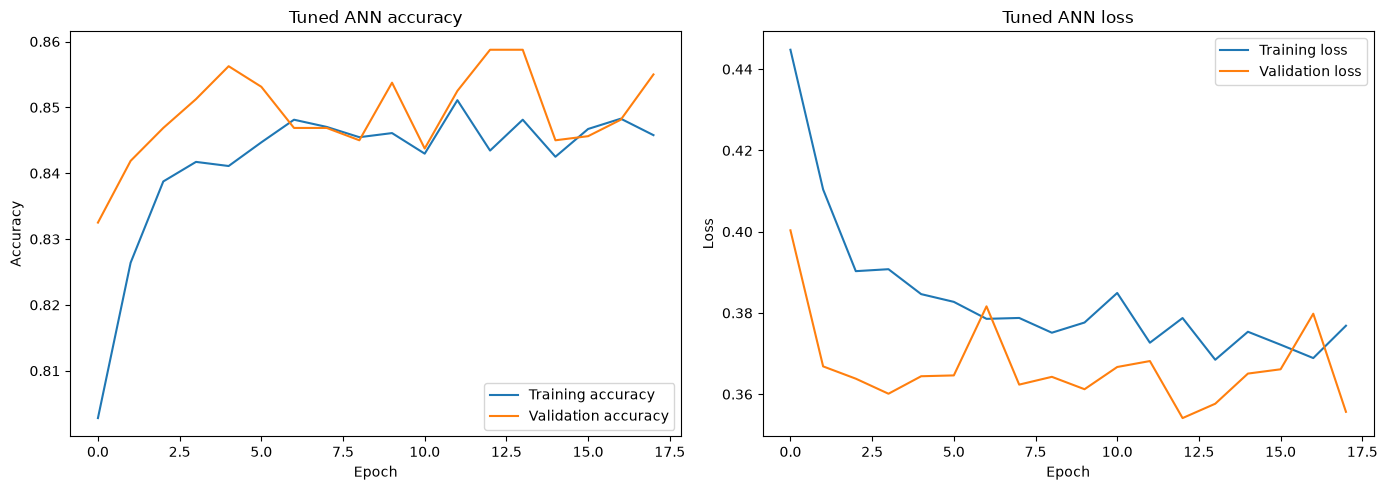

In [101]:
# 8. Plot tuned ANN training and validation performance

history_tuned_df = pd.DataFrame(history_tuned_ann.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_tuned_df["accuracy"], label="Training accuracy")
axes[0].plot(history_tuned_df["val_accuracy"], label="Validation accuracy")
axes[0].set_title("Tuned ANN accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history_tuned_df["loss"], label="Training loss")
axes[1].plot(history_tuned_df["val_loss"], label="Validation loss")
axes[1].set_title("Tuned ANN loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

Best tuned ANN checkpoint reloaded successfully.

Tuned ANN training-validation results:


,Dataset,Accuracy,Balanced accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC (Average Precision),Loss
0,Training,0.8572,0.6883,0.7946,0.4034,0.5351,0.8620,0.6925,0.3505
1,Validation,0.8538,0.6742,0.8067,0.3712,0.5084,0.8554,0.6804,0.3612



Classification report on validation data:
              precision    recall  f1-score   support

 Not churned       0.86      0.98      0.91      1274
     Churned       0.81      0.37      0.51       326

    accuracy                           0.85      1600
   macro avg       0.83      0.67      0.71      1600
weighted avg       0.85      0.85      0.83      1600



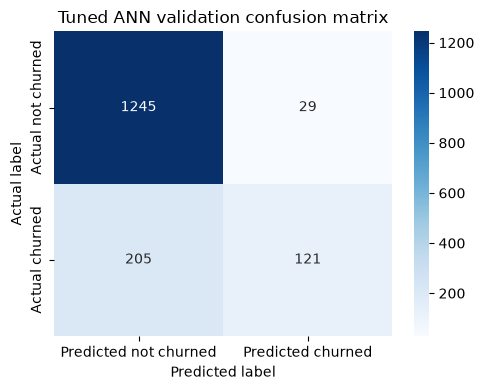

In [102]:
# 9. Reload and evaluate the best tuned ANN checkpoint on training and validation data only

best_tuned_ann_model = tf.keras.models.load_model(
    best_tuned_model_file
)

print(
    "Best tuned ANN checkpoint reloaded successfully."
)

tuned_train_results = evaluate_ann_model(
    model=best_tuned_ann_model,
    X_data=X_train_improved,
    y_true=y_train_improved,
    dataset_name="Training",
    threshold=0.50
)

tuned_val_results = evaluate_ann_model(
    model=best_tuned_ann_model,
    X_data=X_val_improved,
    y_true=y_val_improved,
    dataset_name="Validation",
    threshold=0.50
)

tuned_ann_metrics_df = pd.DataFrame([
    tuned_train_results,
    tuned_val_results
])

print(
    "\nTuned ANN training-validation results:"
)

display(tuned_ann_metrics_df)


# Validation predictions

y_val_pred_proba_tuned = (
    best_tuned_ann_model.predict(
        X_val_improved,
        verbose=0
    ).ravel()
)

y_val_pred_tuned = (
    y_val_pred_proba_tuned >= 0.50
).astype(int)

y_val_tuned_int = np.asarray(
    y_val_improved
).astype(int)


# Validation classification report

print(
    "\nClassification report on validation data:"
)

print(
    classification_report(
        y_val_tuned_int,
        y_val_pred_tuned,
        target_names=[
            "Not churned",
            "Churned"
        ],
        zero_division=0
    )
)


# Validation confusion matrix

cm_tuned_validation = confusion_matrix(
    y_val_tuned_int,
    y_val_pred_tuned
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_tuned_validation,
    annot=True,
    fmt="d",
    cmap="Blues",

    xticklabels=[
        "Predicted not churned",
        "Predicted churned"
    ],

    yticklabels=[
        "Actual not churned",
        "Actual churned"
    ]
)

plt.title(
    "Tuned ANN validation confusion matrix"
)

plt.xlabel("Predicted label")
plt.ylabel("Actual label")

plt.tight_layout()
plt.show()

In [103]:
# 10. Store the tuned ANN result for later comparison

tuned_ann_comparison_result = {
    "Model": "Tuned ANN using KerasTuner",
    "Threshold": 0.50,

    "Train accuracy":
        tuned_train_results["Accuracy"],

    "Validation accuracy":
        tuned_val_results["Accuracy"],

    "Train balanced accuracy":
        tuned_train_results[
            "Balanced accuracy"
        ],

    "Validation balanced accuracy":
        tuned_val_results[
            "Balanced accuracy"
        ],

    "Train precision":
        tuned_train_results["Precision"],

    "Validation precision":
        tuned_val_results["Precision"],

    "Train recall":
        tuned_train_results["Recall"],

    "Validation recall":
        tuned_val_results["Recall"],

    "Train F1-score":
        tuned_train_results["F1-score"],

    "Validation F1-score":
        tuned_val_results["F1-score"],

    "Train ROC-AUC":
        tuned_train_results["ROC-AUC"],

    "Validation ROC-AUC":
        tuned_val_results["ROC-AUC"],

    "Train PR-AUC":
        tuned_train_results[
            "PR-AUC (Average Precision)"
        ],

    "Validation PR-AUC":
        tuned_val_results[
            "PR-AUC (Average Precision)"
        ],

    "Train loss":
        tuned_train_results["Loss"],

    "Validation loss":
        tuned_val_results["Loss"]
}

if "model_results" not in globals():
    model_results = []

model_results = [
    result
    for result in model_results
    if result.get("Model")
    != "Tuned ANN using KerasTuner"
]

model_results.append(
    tuned_ann_comparison_result
)

model_comparison_df = pd.DataFrame(
    model_results
)

display(model_comparison_df)

,Model,Threshold,Train accuracy,Validation accuracy,Train balanced accuracy,Validation balanced accuracy,Train precision,Validation precision,Train recall,Validation recall,Train F1-score,Validation F1-score,Train ROC-AUC,Validation ROC-AUC,Train PR-AUC,Validation PR-AUC,Train loss,Validation loss
0,Class-weighted Improved ANN,0.5,0.8128,0.7987,0.7980,0.7789,0.5277,0.5041,0.7730,0.7454,0.6273,0.6015,0.8894,0.8578,0.7399,0.6842,0.3948,0.4266
1,Class-weighted Improved ANN with tuned threshold,0.6,0.8506,0.8375,0.7858,0.7610,0.6229,0.5954,0.6764,0.6319,0.6485,0.6131,0.8894,0.8578,0.7399,0.6842,0.3948,0.4266
2,Improved ANN with tuned threshold,0.3,0.8509,0.8462,0.7740,0.7654,0.6316,0.6212,0.6442,0.6288,0.6378,0.6250,0.8801,0.8602,0.7313,0.6920,0.3175,0.3423
3,Basic ANN,0.5,0.8894,0.8519,0.7793,0.7061,0.8130,0.7109,0.5936,0.4601,0.6862,0.5587,0.9239,0.8399,0.8118,0.6500,0.2599,0.3897
4,"Improved ANN with Dropout, EarlyStopping, and ...",0.5,0.8703,0.8625,0.7325,0.7174,0.7855,0.7624,0.5000,0.4724,0.6111,0.5833,0.8801,0.8602,0.7313,0.6920,0.3175,0.3423
5,Tuned ANN using KerasTuner,0.5,0.8572,0.8538,0.6883,0.6742,0.7946,0.8067,0.4034,0.3712,0.5351,0.5084,0.8620,0.8554,0.6925,0.6804,0.3505,0.3612


### Hyperparameter tuning using KerasTuner — key insights

1. KerasTuner RandomSearch evaluated **8 hyperparameter combinations** using only the fixed modelling-training and validation partitions.

2. Validation PR-AUC was used as the tuner objective because churn is the minority class and accuracy alone can overstate model performance.

3. The loss function remained fixed as `binary_crossentropy`, which is technically appropriate for a binary target with a sigmoid output layer.

4. The best hyperparameter combination selected by KerasTuner was:

   - Hidden layers: **4**
   - Layer 1: **128 neurons**, `tanh`, dropout **0.30**
   - Layer 2: **48 neurons**, `tanh`, dropout **0.40**
   - Layer 3: **64 neurons**, `relu`, dropout **0.10**
   - Layer 4: **112 neurons**, `relu`, dropout **0.30**
   - Optimiser: **Adam**
   - Learning rate: **0.01**
   - Batch size: **64**

5. The best tuner trial reached a validation Keras PR-AUC of approximately **0.6889**.

6. A fresh ANN was built using the selected hyperparameters, and the best complete model was saved by monitoring validation PR-AUC.

7. EarlyStopping restored the model weights from the best epoch, and the saved best tuned checkpoint was explicitly reloaded before evaluation.

8. The Tuned ANN achieved **85.72% training accuracy** and **85.38% validation accuracy**, giving a small accuracy gap of approximately **0.34 percentage points**.

9. Validation ROC-AUC was **0.8554**, while validation PR-AUC measured using Average Precision was **0.6804**.

10. At the default threshold of **0.50**, validation churn precision was high at **80.67%**, but churn recall was only **37.12%**.

11. The validation confusion matrix shows:

   - True negatives: **1,245**
   - False positives: **29**
   - False negatives: **205**
   - True positives: **121**

12. The Tuned ANN made fewer false churn predictions than the previous models, but it missed **205 of 326** actual churned customers.

13. Compared with the Improved ANN, the Tuned ANN produced higher validation precision:

   - Improved ANN: **0.7624**
   - Tuned ANN: **0.8067**

14. However, the Tuned ANN performed worse than the Improved ANN on the main validation measures:

   - Accuracy: **0.8538 vs 0.8625**
   - Balanced accuracy: **0.6742 vs 0.7174**
   - Recall: **0.3712 vs 0.4724**
   - F1-score: **0.5084 vs 0.5833**
   - ROC-AUC: **0.8554 vs 0.8602**
   - PR-AUC: **0.6804 vs 0.6920**
   - Loss: **0.3612 vs 0.3423**

15. Hyperparameter tuning therefore did not improve the ANN overall. It produced a more conservative model with higher precision but substantially lower churn recall and F1-score.

16. Based on the results currently available, the Improved ANN remains the stronger validation model, but final selection must wait until the approved class-imbalance and threshold experiments are completed.

----

# 10A. Class imbalance handling using class weights

The churn target is imbalanced, with churned customers representing the minority class.

The Basic, Improved and Tuned ANN models achieved useful overall performance, but churn recall remained limited. Class weighting will therefore be evaluated as an additional approved experiment.

In this section:

- Class weights will be calculated using only the modelling-training target
- A class-weighted version of the Improved ANN will be trained
- ModelCheckpoint will save the best complete model
- The best saved checkpoint will be explicitly reloaded
- Performance will be evaluated on training and validation data only
- The classification threshold will be tuned using validation F1-score
- Both the default-threshold and tuned-threshold results will be added to the validation comparison

The test set will not be evaluated or used during class-weight testing, threshold tuning or model selection.

In [104]:
# 10A.1 Calculate class weights for imbalanced target

from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd

y_train_class_weighted_int = y_train_improved.astype(int)

classes = np.unique(y_train_class_weighted_int)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_class_weighted_int
)

class_weight_dict = {
    int(class_label): float(class_weight)
    for class_label, class_weight in zip(classes, class_weights_array)
}

class_weight_summary = pd.DataFrame({
    "Class": classes,
    "Class label": ["Not churned" if c == 0 else "Churned" for c in classes],
    "Training count": [np.sum(y_train_class_weighted_int == c) for c in classes],
    "Class weight": [class_weight_dict[int(c)] for c in classes]
})

print("Class weights calculated successfully.")
display(class_weight_summary)
print("Class weight dictionary:", class_weight_dict)

Class weights calculated successfully.


,Class,Class label,Training count,Class weight
0,0,Not churned,5096,0.627943
1,1,Churned,1304,2.453988


Class weight dictionary: {0: 0.6279434850863422, 1: 2.4539877300613497}


In [105]:
# 10A.2 Build class-weighted Improved ANN model

import tensorflow as tf
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

tf.keras.backend.clear_session()

input_dim_class_weighted = X_train_improved.shape[1]

class_weighted_ann_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim_class_weighted,)),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.30),

    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.20),

    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dropout(0.10),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

class_weighted_ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

class_weighted_ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [106]:
# 10A.3 Define callbacks for class-weighted ANN

import os
import glob

os.makedirs("checkpoints", exist_ok=True)
os.makedirs("models", exist_ok=True)

# Remove old class-weighted checkpoint files if this section is rerun
old_class_weighted_checkpoint_files = glob.glob("checkpoints/class_weighted_ann_epoch_*.weights.h5")

for file in old_class_weighted_checkpoint_files:
    os.remove(file)

old_class_weighted_best_model_file = "models/best_class_weighted_ann_model.keras"

if os.path.exists(old_class_weighted_best_model_file):
    os.remove(old_class_weighted_best_model_file)

early_stopping_class_weighted = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

checkpoint_each_epoch_class_weighted = tf.keras.callbacks.ModelCheckpoint(
    filepath="checkpoints/class_weighted_ann_epoch_{epoch:02d}.weights.h5",
    monitor="val_loss",
    save_best_only=False,
    save_weights_only=True,
    verbose=0
)

best_model_checkpoint_class_weighted = tf.keras.callbacks.ModelCheckpoint(
    filepath="models/best_class_weighted_ann_model.keras",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

callbacks_class_weighted = [
    early_stopping_class_weighted,
    checkpoint_each_epoch_class_weighted,
    best_model_checkpoint_class_weighted
]

print("Class-weighted ANN callbacks created successfully.")

Class-weighted ANN callbacks created successfully.


In [107]:
# 10A.4 Train class-weighted ANN model

history_class_weighted_ann = class_weighted_ann_model.fit(
    X_train_improved,
    y_train_improved,
    validation_data=(X_val_improved, y_val_improved),
    epochs=100,
    batch_size=32,
    callbacks=callbacks_class_weighted,
    class_weight=class_weight_dict,
    verbose=1,
    shuffle=True
)

Epoch 1/100
191/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6147 - auc: 0.6947 - loss: 0.6404 - precision: 0.3051 - recall: 0.7013
Epoch 1: val_loss improved from None to 0.54624, saving model to models/best_class_weighted_ann_model.keras

Epoch 1: finished saving model to models/best_class_weighted_ann_model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6192 - auc: 0.6999 - loss: 0.6373 - precision: 0.3095 - recall: 0.7055 - val_accuracy: 0.7412 - val_auc: 0.7839 - val_loss: 0.5462 - val_precision: 0.4176 - val_recall: 0.6840
Epoch 2/100
191/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7057 - auc: 0.7776 - loss: 0.5735 - precision: 0.3836 - recall: 0.7391
Epoch 2: val_loss improved from 0.54624 to 0.51417, saving model to models/best_class_weighted_ann_model.keras

Epoch 2: finished saving model to models/best_class_weighted_ann_model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7069 - auc: 0.7799 - loss: 0.5715 - precision: 0.3860 - recall:

In [108]:
# 10A.5 Check saved checkpoint files

class_weighted_epoch_checkpoint_files = sorted(
    glob.glob("checkpoints/class_weighted_ann_epoch_*.weights.h5")
)

class_weighted_best_model_file = "models/best_class_weighted_ann_model.keras"

print("Number of class-weighted epoch checkpoint files saved:", len(class_weighted_epoch_checkpoint_files))

if len(class_weighted_epoch_checkpoint_files) > 0:
    print("\nFirst few checkpoint files:")
    print(class_weighted_epoch_checkpoint_files[:3])

    print("\nLast few checkpoint files:")
    print(class_weighted_epoch_checkpoint_files[-3:])

print("\nBest class-weighted model file exists:", os.path.exists(class_weighted_best_model_file))

Number of class-weighted epoch checkpoint files saved: 38

First few checkpoint files:
['checkpoints/class_weighted_ann_epoch_01.weights.h5', 'checkpoints/class_weighted_ann_epoch_02.weights.h5', 'checkpoints/class_weighted_ann_epoch_03.weights.h5']

Last few checkpoint files:
['checkpoints/class_weighted_ann_epoch_36.weights.h5', 'checkpoints/class_weighted_ann_epoch_37.weights.h5', 'checkpoints/class_weighted_ann_epoch_38.weights.h5']

Best class-weighted model file exists: True


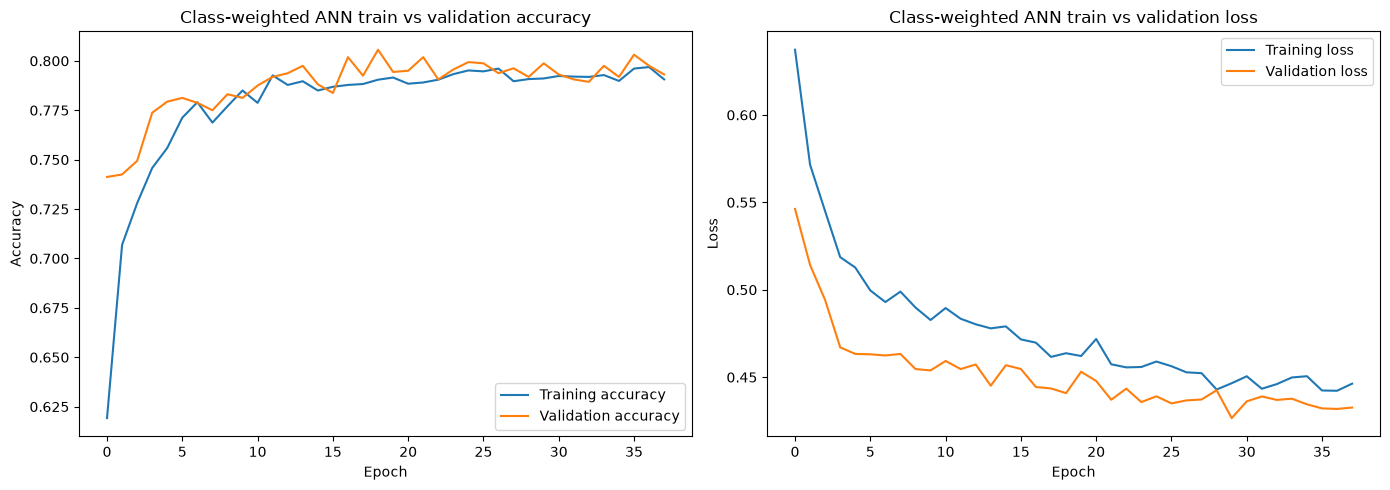

In [109]:
# 10A.6 Plot class-weighted ANN training and validation performance

import matplotlib.pyplot as plt

history_class_weighted_df = pd.DataFrame(history_class_weighted_ann.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_class_weighted_df["accuracy"], label="Training accuracy")
axes[0].plot(history_class_weighted_df["val_accuracy"], label="Validation accuracy")
axes[0].set_title("Class-weighted ANN train vs validation accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history_class_weighted_df["loss"], label="Training loss")
axes[1].plot(history_class_weighted_df["val_loss"], label="Validation loss")
axes[1].set_title("Class-weighted ANN train vs validation loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

Best class-weighted ANN checkpoint reloaded successfully.

Class-weighted ANN training-validation results at threshold 0.50:


,Dataset,Accuracy,Balanced accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC (Average Precision),Loss
0,Training,0.8128,0.7980,0.5277,0.7730,0.6273,0.8894,0.7399,0.3948
1,Validation,0.7987,0.7789,0.5041,0.7454,0.6015,0.8578,0.6842,0.4266



Classification report on validation data:
              precision    recall  f1-score   support

 Not churned       0.93      0.81      0.87      1274
     Churned       0.50      0.75      0.60       326

    accuracy                           0.80      1600
   macro avg       0.71      0.78      0.73      1600
weighted avg       0.84      0.80      0.81      1600



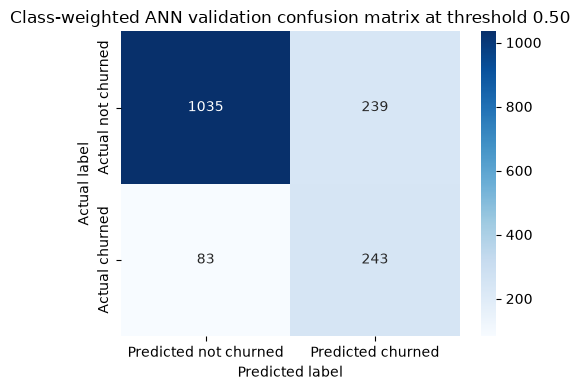

In [110]:
# 10A.7 Reload and evaluate the best class-weighted ANN checkpoint on training and validation data only

class_weighted_ann_model = tf.keras.models.load_model(
    class_weighted_best_model_file
)

print(
    "Best class-weighted ANN checkpoint "
    "reloaded successfully."
)


class_weighted_train_results = evaluate_ann_model(
    model=class_weighted_ann_model,
    X_data=X_train_improved,
    y_true=y_train_improved,
    dataset_name="Training",
    threshold=0.50
)

class_weighted_val_results = evaluate_ann_model(
    model=class_weighted_ann_model,
    X_data=X_val_improved,
    y_true=y_val_improved,
    dataset_name="Validation",
    threshold=0.50
)


class_weighted_metrics_df = pd.DataFrame([
    class_weighted_train_results,
    class_weighted_val_results
])

print(
    "\nClass-weighted ANN training-validation "
    "results at threshold 0.50:"
)

display(class_weighted_metrics_df)


# Validation predictions

y_val_proba_class_weighted = (
    class_weighted_ann_model.predict(
        X_val_improved,
        verbose=0
    ).ravel()
)

y_val_pred_class_weighted = (
    y_val_proba_class_weighted >= 0.50
).astype(int)

y_val_class_weighted_int = np.asarray(
    y_val_improved
).astype(int)


print(
    "\nClassification report on validation data:"
)

print(
    classification_report(
        y_val_class_weighted_int,
        y_val_pred_class_weighted,
        target_names=[
            "Not churned",
            "Churned"
        ],
        zero_division=0
    )
)


cm_class_weighted_validation = confusion_matrix(
    y_val_class_weighted_int,
    y_val_pred_class_weighted
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_class_weighted_validation,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted not churned",
        "Predicted churned"
    ],
    yticklabels=[
        "Actual not churned",
        "Actual churned"
    ]
)

plt.title(
    "Class-weighted ANN validation confusion matrix "
    "at threshold 0.50"
)

plt.xlabel("Predicted label")
plt.ylabel("Actual label")

plt.tight_layout()
plt.show()

In [111]:
# 10A.8 Store the default-threshold class-weighted result

class_weighted_ann_comparison_result = {
    "Model": "Class-weighted Improved ANN",
    "Threshold": 0.50,

    "Train accuracy":
        class_weighted_train_results["Accuracy"],

    "Validation accuracy":
        class_weighted_val_results["Accuracy"],

    "Train balanced accuracy":
        class_weighted_train_results[
            "Balanced accuracy"
        ],

    "Validation balanced accuracy":
        class_weighted_val_results[
            "Balanced accuracy"
        ],

    "Train precision":
        class_weighted_train_results["Precision"],

    "Validation precision":
        class_weighted_val_results["Precision"],

    "Train recall":
        class_weighted_train_results["Recall"],

    "Validation recall":
        class_weighted_val_results["Recall"],

    "Train F1-score":
        class_weighted_train_results["F1-score"],

    "Validation F1-score":
        class_weighted_val_results["F1-score"],

    "Train ROC-AUC":
        class_weighted_train_results["ROC-AUC"],

    "Validation ROC-AUC":
        class_weighted_val_results["ROC-AUC"],

    "Train PR-AUC":
        class_weighted_train_results[
            "PR-AUC (Average Precision)"
        ],

    "Validation PR-AUC":
        class_weighted_val_results[
            "PR-AUC (Average Precision)"
        ],

    "Train loss":
        class_weighted_train_results["Loss"],

    "Validation loss":
        class_weighted_val_results["Loss"]
}


if "model_results" not in globals():
    model_results = []


model_results = [
    result
    for result in model_results
    if result.get("Model")
    != "Class-weighted Improved ANN"
]


model_results.append(
    class_weighted_ann_comparison_result
)


model_comparison_df = pd.DataFrame(
    model_results
)

display(model_comparison_df)

,Model,Threshold,Train accuracy,Validation accuracy,Train balanced accuracy,Validation balanced accuracy,Train precision,Validation precision,Train recall,Validation recall,Train F1-score,Validation F1-score,Train ROC-AUC,Validation ROC-AUC,Train PR-AUC,Validation PR-AUC,Train loss,Validation loss
0,Class-weighted Improved ANN with tuned threshold,0.6,0.8506,0.8375,0.7858,0.7610,0.6229,0.5954,0.6764,0.6319,0.6485,0.6131,0.8894,0.8578,0.7399,0.6842,0.3948,0.4266
1,Improved ANN with tuned threshold,0.3,0.8509,0.8462,0.7740,0.7654,0.6316,0.6212,0.6442,0.6288,0.6378,0.6250,0.8801,0.8602,0.7313,0.6920,0.3175,0.3423
2,Basic ANN,0.5,0.8894,0.8519,0.7793,0.7061,0.8130,0.7109,0.5936,0.4601,0.6862,0.5587,0.9239,0.8399,0.8118,0.6500,0.2599,0.3897
3,"Improved ANN with Dropout, EarlyStopping, and ...",0.5,0.8703,0.8625,0.7325,0.7174,0.7855,0.7624,0.5000,0.4724,0.6111,0.5833,0.8801,0.8602,0.7313,0.6920,0.3175,0.3423
4,Tuned ANN using KerasTuner,0.5,0.8572,0.8538,0.6883,0.6742,0.7946,0.8067,0.4034,0.3712,0.5351,0.5084,0.8620,0.8554,0.6925,0.6804,0.3505,0.3612
5,Class-weighted Improved ANN,0.5,0.8128,0.7987,0.7980,0.7789,0.5277,0.5041,0.7730,0.7454,0.6273,0.6015,0.8894,0.8578,0.7399,0.6842,0.3948,0.4266


In [112]:
# 10A.9 Tune the class-weighted ANN threshold using validation F1-score

threshold_values = np.arange(
    0.20,
    0.81,
    0.01
)

y_val_proba_class_weighted = (
    class_weighted_ann_model.predict(
        X_val_improved,
        verbose=0
    ).ravel()
)

y_val_class_weighted_int = np.asarray(
    y_val_improved
).astype(int)

class_weighted_threshold_results = []


for threshold in threshold_values:

    y_val_pred_threshold = (
        y_val_proba_class_weighted >= threshold
    ).astype(int)

    class_weighted_threshold_results.append({
        "Threshold": round(
            float(threshold),
            2
        ),

        "Validation accuracy": round(
            accuracy_score(
                y_val_class_weighted_int,
                y_val_pred_threshold
            ),
            4
        ),

        "Validation balanced accuracy": round(
            balanced_accuracy_score(
                y_val_class_weighted_int,
                y_val_pred_threshold
            ),
            4
        ),

        "Validation precision": round(
            precision_score(
                y_val_class_weighted_int,
                y_val_pred_threshold,
                zero_division=0
            ),
            4
        ),

        "Validation recall": round(
            recall_score(
                y_val_class_weighted_int,
                y_val_pred_threshold,
                zero_division=0
            ),
            4
        ),

        "Validation F1-score": round(
            f1_score(
                y_val_class_weighted_int,
                y_val_pred_threshold,
                zero_division=0
            ),
            4
        )
    })


class_weighted_threshold_df = pd.DataFrame(
    class_weighted_threshold_results
)


best_class_weighted_threshold_row = (
    class_weighted_threshold_df
    .sort_values(
        by=[
            "Validation F1-score",
            "Validation recall"
        ],
        ascending=False
    )
    .iloc[0]
)


best_class_weighted_threshold = float(
    best_class_weighted_threshold_row[
        "Threshold"
    ]
)


print(
    "Best threshold for class-weighted ANN:",
    best_class_weighted_threshold
)

print(
    "\nTop 10 thresholds by validation F1-score:"
)

display(
    class_weighted_threshold_df
    .sort_values(
        by=[
            "Validation F1-score",
            "Validation recall"
        ],
        ascending=False
    )
    .head(10)
)

Best threshold for class-weighted ANN: 0.6

Top 10 thresholds by validation F1-score:


,Threshold,Validation accuracy,Validation balanced accuracy,Validation precision,Validation recall,Validation F1-score
40,0.60,0.8375,0.7610,0.5954,0.6319,0.6131
39,0.59,0.8337,0.7632,0.5833,0.6442,0.6122
41,0.61,0.8400,0.7569,0.6054,0.6166,0.6109
36,0.56,0.8250,0.7680,0.5587,0.6718,0.6100
38,0.58,0.8300,0.7631,0.5730,0.6503,0.6092
37,0.57,0.8269,0.7646,0.5643,0.6595,0.6082
42,0.62,0.8425,0.7516,0.6171,0.5982,0.6075
43,0.63,0.8444,0.7471,0.6271,0.5828,0.6041
45,0.65,0.8481,0.7437,0.6446,0.5675,0.6036
35,0.55,0.8181,0.7660,0.5430,0.6779,0.6030


Class-weighted ANN training-validation results using the tuned threshold:


,Dataset,Accuracy,Balanced accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC (Average Precision),Loss
0,Training,0.8506,0.7858,0.6229,0.6764,0.6485,0.8894,0.7399,0.3948
1,Validation,0.8375,0.7610,0.5954,0.6319,0.6131,0.8578,0.6842,0.4266



Classification report on validation data:
              precision    recall  f1-score   support

 Not churned       0.90      0.89      0.90      1274
     Churned       0.60      0.63      0.61       326

    accuracy                           0.84      1600
   macro avg       0.75      0.76      0.76      1600
weighted avg       0.84      0.84      0.84      1600



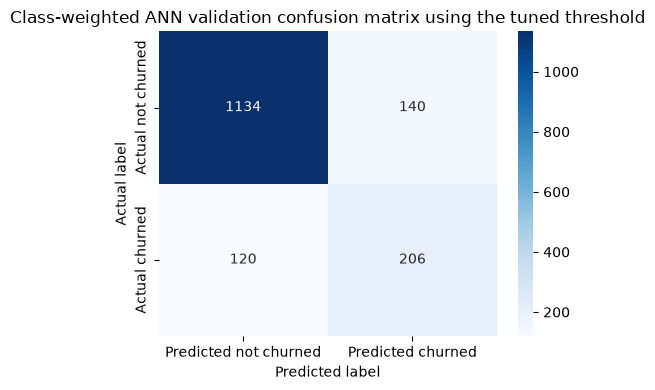

In [113]:
# 10A.10 Evaluate the class-weighted ANN using the tuned threshold on training and validation data only

class_weighted_threshold_train_results = (
    evaluate_ann_model(
        model=class_weighted_ann_model,
        X_data=X_train_improved,
        y_true=y_train_improved,
        dataset_name="Training",
        threshold=best_class_weighted_threshold
    )
)

class_weighted_threshold_val_results = (
    evaluate_ann_model(
        model=class_weighted_ann_model,
        X_data=X_val_improved,
        y_true=y_val_improved,
        dataset_name="Validation",
        threshold=best_class_weighted_threshold
    )
)


class_weighted_threshold_metrics_df = pd.DataFrame([
    class_weighted_threshold_train_results,
    class_weighted_threshold_val_results
])


print(
    "Class-weighted ANN training-validation results "
    "using the tuned threshold:"
)

display(
    class_weighted_threshold_metrics_df
)


# Validation predictions using the tuned threshold

y_val_pred_class_weighted_threshold = (
    y_val_proba_class_weighted
    >= best_class_weighted_threshold
).astype(int)


print(
    "\nClassification report on validation data:"
)

print(
    classification_report(
        y_val_class_weighted_int,
        y_val_pred_class_weighted_threshold,
        target_names=[
            "Not churned",
            "Churned"
        ],
        zero_division=0
    )
)


cm_class_weighted_threshold_validation = (
    confusion_matrix(
        y_val_class_weighted_int,
        y_val_pred_class_weighted_threshold
    )
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_class_weighted_threshold_validation,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted not churned",
        "Predicted churned"
    ],
    yticklabels=[
        "Actual not churned",
        "Actual churned"
    ]
)

plt.title(
    "Class-weighted ANN validation confusion matrix "
    "using the tuned threshold"
)

plt.xlabel("Predicted label")
plt.ylabel("Actual label")

plt.tight_layout()
plt.show()

In [114]:
# 10A.11 Store the tuned-threshold class-weighted result

class_weighted_threshold_comparison_result = {
    "Model": (
        "Class-weighted Improved ANN "
        "with tuned threshold"
    ),

    "Threshold":
        best_class_weighted_threshold,

    "Train accuracy":
        class_weighted_threshold_train_results[
            "Accuracy"
        ],

    "Validation accuracy":
        class_weighted_threshold_val_results[
            "Accuracy"
        ],

    "Train balanced accuracy":
        class_weighted_threshold_train_results[
            "Balanced accuracy"
        ],

    "Validation balanced accuracy":
        class_weighted_threshold_val_results[
            "Balanced accuracy"
        ],

    "Train precision":
        class_weighted_threshold_train_results[
            "Precision"
        ],

    "Validation precision":
        class_weighted_threshold_val_results[
            "Precision"
        ],

    "Train recall":
        class_weighted_threshold_train_results[
            "Recall"
        ],

    "Validation recall":
        class_weighted_threshold_val_results[
            "Recall"
        ],

    "Train F1-score":
        class_weighted_threshold_train_results[
            "F1-score"
        ],

    "Validation F1-score":
        class_weighted_threshold_val_results[
            "F1-score"
        ],

    "Train ROC-AUC":
        class_weighted_threshold_train_results[
            "ROC-AUC"
        ],

    "Validation ROC-AUC":
        class_weighted_threshold_val_results[
            "ROC-AUC"
        ],

    "Train PR-AUC":
        class_weighted_threshold_train_results[
            "PR-AUC (Average Precision)"
        ],

    "Validation PR-AUC":
        class_weighted_threshold_val_results[
            "PR-AUC (Average Precision)"
        ],

    "Train loss":
        class_weighted_threshold_train_results[
            "Loss"
        ],

    "Validation loss":
        class_weighted_threshold_val_results[
            "Loss"
        ]
}


if "model_results" not in globals():
    model_results = []


model_results = [
    result
    for result in model_results
    if result.get("Model") != (
        "Class-weighted Improved ANN "
        "with tuned threshold"
    )
]


model_results.append(
    class_weighted_threshold_comparison_result
)


model_comparison_df = pd.DataFrame(
    model_results
)

display(model_comparison_df)

,Model,Threshold,Train accuracy,Validation accuracy,Train balanced accuracy,Validation balanced accuracy,Train precision,Validation precision,Train recall,Validation recall,Train F1-score,Validation F1-score,Train ROC-AUC,Validation ROC-AUC,Train PR-AUC,Validation PR-AUC,Train loss,Validation loss
0,Improved ANN with tuned threshold,0.3,0.8509,0.8462,0.7740,0.7654,0.6316,0.6212,0.6442,0.6288,0.6378,0.6250,0.8801,0.8602,0.7313,0.6920,0.3175,0.3423
1,Basic ANN,0.5,0.8894,0.8519,0.7793,0.7061,0.8130,0.7109,0.5936,0.4601,0.6862,0.5587,0.9239,0.8399,0.8118,0.6500,0.2599,0.3897
2,"Improved ANN with Dropout, EarlyStopping, and ...",0.5,0.8703,0.8625,0.7325,0.7174,0.7855,0.7624,0.5000,0.4724,0.6111,0.5833,0.8801,0.8602,0.7313,0.6920,0.3175,0.3423
3,Tuned ANN using KerasTuner,0.5,0.8572,0.8538,0.6883,0.6742,0.7946,0.8067,0.4034,0.3712,0.5351,0.5084,0.8620,0.8554,0.6925,0.6804,0.3505,0.3612
4,Class-weighted Improved ANN,0.5,0.8128,0.7987,0.7980,0.7789,0.5277,0.5041,0.7730,0.7454,0.6273,0.6015,0.8894,0.8578,0.7399,0.6842,0.3948,0.4266
5,Class-weighted Improved ANN with tuned threshold,0.6,0.8506,0.8375,0.7858,0.7610,0.6229,0.5954,0.6764,0.6319,0.6485,0.6131,0.8894,0.8578,0.7399,0.6842,0.3948,0.4266


### Class imbalance handling using class weights — key insights

1. The modelling-training data contained **5,096 non-churned customers** and **1,304 churned customers**. The calculated class weights were:

   - Not churned: **0.6279**
   - Churned: **2.4540**

2. The higher weight assigned to the churn class increased the penalty for incorrectly classifying churned customers and encouraged the ANN to detect more minority-class cases.

3. The class-weighted ANN used the same Improved ANN architecture with Dropout, EarlyStopping and ModelCheckpoint. Training stopped after **38 epochs**, and the best weights from **epoch 30** were restored.

4. ModelCheckpoint saved weights after every epoch, producing **38 checkpoint files**, and the best complete class-weighted model was saved separately and explicitly reloaded before evaluation.

5. At the default threshold of **0.50**, the class-weighted ANN achieved:

   - Validation accuracy: **0.7987**
   - Validation balanced accuracy: **0.7789**
   - Validation precision: **0.5041**
   - Validation recall: **0.7454**
   - Validation F1-score: **0.6015**
   - Validation ROC-AUC: **0.8578**
   - Validation PR-AUC: **0.6842**

6. At threshold 0.50, the model identified **243 of 326 churned customers** and missed only **83**. This was a substantial recall improvement over the unweighted Improved ANN, whose validation recall was **0.4724**.

7. The recall improvement came with a trade-off. The class-weighted model generated **239 false-positive churn predictions**, reducing validation precision and overall accuracy.

8. Threshold tuning was performed using validation F1-score only. The best threshold was **0.60**, with a validation F1-score of **0.6131**.

9. At threshold 0.60, the class-weighted ANN achieved:

   - Validation accuracy: **0.8375**
   - Validation balanced accuracy: **0.7610**
   - Validation precision: **0.5954**
   - Validation recall: **0.6319**
   - Validation F1-score: **0.6131**

10. Raising the threshold from 0.50 to 0.60 reduced false positives from **239 to 140** and increased precision from **0.5041 to 0.5954**.

11. The higher threshold reduced true positives from **243 to 206**, causing recall to decrease from **0.7454 to 0.6319**. However, the improved precision produced a higher overall F1-score.

12. ROC-AUC and PR-AUC remained unchanged across the two thresholds because they are calculated from predicted probabilities rather than one fixed classification threshold.

13. Compared with the unweighted Improved ANN, the class-weighted model with threshold 0.60 produced:

   - Lower validation accuracy: **0.8375 vs 0.8625**
   - Lower precision: **0.5954 vs 0.7624**
   - Higher recall: **0.6319 vs 0.4724**
   - Higher F1-score: **0.6131 vs 0.5833**
   - Higher balanced accuracy: **0.7610 vs 0.7174**

14. The class-weighted ANN with threshold **0.60** currently provides the strongest balance between churn precision and recall and has the highest validation F1-score among the evaluated candidates.

15. Final model selection must be based on the complete validation comparison before the selected model and threshold are evaluated once on the reserved test set.

---

# 10B. Validation-based model comparison and model recommendation

In this section, all approved ANN candidates will be compared using training and validation results only.

The six candidates are:

- Basic ANN
- Improved ANN with Dropout, EarlyStopping, and ModelCheckpoint
- Improved ANN with tuned threshold
- Tuned ANN using KerasTuner
- Class-weighted Improved ANN
- Class-weighted Improved ANN with tuned threshold

The decision threshold for the unweighted Improved ANN will first be tuned using validation F1-score.

Because the churn target is imbalanced, the model recommendation will use:

1. Validation F1-score as the primary criterion
2. Validation PR-AUC
3. Validation ROC-AUC
4. Validation balanced accuracy
5. Training-validation gaps as evidence of overfitting

The test set will not be evaluated or used during threshold tuning, model comparison or model recommendation.

The recommended model and threshold will be reviewed before they are locked for final test evaluation.

In [115]:
# 10B.1 — Tune the decision threshold for the Improved ANN using validation F1-score only

improved_threshold_values = np.round(
    np.arange(0.20, 0.81, 0.01),
    2
)

y_val_proba_improved = improved_ann_model.predict(
    X_val_improved,
    verbose=0
).ravel()

y_val_improved_int = np.asarray(
    y_val_improved
).astype(int)

improved_threshold_results = []

for threshold in improved_threshold_values:

    y_val_pred_threshold = (
        y_val_proba_improved >= threshold
    ).astype(int)

    improved_threshold_results.append({
        "Threshold": float(threshold),

        "Validation accuracy": accuracy_score(
            y_val_improved_int,
            y_val_pred_threshold
        ),

        "Validation balanced accuracy":
            balanced_accuracy_score(
                y_val_improved_int,
                y_val_pred_threshold
            ),

        "Validation precision": precision_score(
            y_val_improved_int,
            y_val_pred_threshold,
            zero_division=0
        ),

        "Validation recall": recall_score(
            y_val_improved_int,
            y_val_pred_threshold,
            zero_division=0
        ),

        "Validation F1-score": f1_score(
            y_val_improved_int,
            y_val_pred_threshold,
            zero_division=0
        )
    })


improved_threshold_df = pd.DataFrame(
    improved_threshold_results
)


best_improved_threshold_row = (
    improved_threshold_df
    .sort_values(
        by=[
            "Validation F1-score",
            "Validation balanced accuracy",
            "Validation recall"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .iloc[0]
)


best_improved_threshold = float(
    best_improved_threshold_row["Threshold"]
)


print(
    "Best threshold for the Improved ANN:",
    best_improved_threshold
)

print(
    "\nTop 10 Improved ANN thresholds "
    "by validation F1-score:"
)

display(
    improved_threshold_df
    .sort_values(
        by=[
            "Validation F1-score",
            "Validation balanced accuracy",
            "Validation recall"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .head(10)
    .round(4)
)

Best threshold for the Improved ANN: 0.3

Top 10 Improved ANN thresholds by validation F1-score:


,Threshold,Validation accuracy,Validation balanced accuracy,Validation precision,Validation recall,Validation F1-score
10,0.30,0.8462,0.7654,0.6212,0.6288,0.6250
9,0.29,0.8438,0.7672,0.6118,0.6380,0.6246
11,0.31,0.8481,0.7585,0.6326,0.6074,0.6197
8,0.28,0.8369,0.7652,0.5915,0.6442,0.6167
6,0.26,0.8294,0.7707,0.5688,0.6718,0.6160
12,0.32,0.8488,0.7544,0.6382,0.5951,0.6159
13,0.33,0.8494,0.7525,0.6421,0.5890,0.6144
14,0.34,0.8506,0.7510,0.6485,0.5828,0.6139
7,0.27,0.8319,0.7655,0.5772,0.6534,0.6129
5,0.25,0.8244,0.7699,0.5567,0.6779,0.6113


Improved ANN training-validation results using the tuned threshold:


,Dataset,Accuracy,Balanced accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC (Average Precision),Loss
0,Training,0.8509,0.7740,0.6316,0.6442,0.6378,0.8801,0.7313,0.3175
1,Validation,0.8462,0.7654,0.6212,0.6288,0.6250,0.8602,0.6920,0.3423



Classification report on validation data:
              precision    recall  f1-score   support

 Not churned       0.90      0.90      0.90      1274
     Churned       0.62      0.63      0.62       326

    accuracy                           0.85      1600
   macro avg       0.76      0.77      0.76      1600
weighted avg       0.85      0.85      0.85      1600



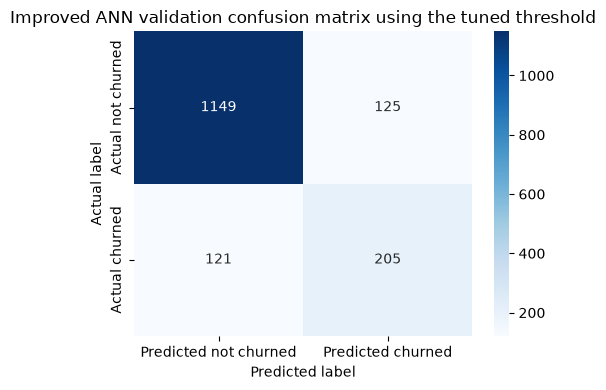

In [116]:
# 10B.2 — Evaluate and store the Improved ANN using its validation-tuned threshold

improved_threshold_train_results = evaluate_ann_model(
    model=improved_ann_model,
    X_data=X_train_improved,
    y_true=y_train_improved,
    dataset_name="Training",
    threshold=best_improved_threshold
)

improved_threshold_val_results = evaluate_ann_model(
    model=improved_ann_model,
    X_data=X_val_improved,
    y_true=y_val_improved,
    dataset_name="Validation",
    threshold=best_improved_threshold
)


improved_threshold_metrics_df = pd.DataFrame([
    improved_threshold_train_results,
    improved_threshold_val_results
])

print(
    "Improved ANN training-validation results "
    "using the tuned threshold:"
)

display(improved_threshold_metrics_df)


y_val_pred_improved_threshold = (
    y_val_proba_improved >= best_improved_threshold
).astype(int)


print(
    "\nClassification report on validation data:"
)

print(
    classification_report(
        y_val_improved_int,
        y_val_pred_improved_threshold,
        target_names=[
            "Not churned",
            "Churned"
        ],
        zero_division=0
    )
)


cm_improved_threshold_validation = confusion_matrix(
    y_val_improved_int,
    y_val_pred_improved_threshold
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_improved_threshold_validation,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted not churned",
        "Predicted churned"
    ],
    yticklabels=[
        "Actual not churned",
        "Actual churned"
    ]
)

plt.title(
    "Improved ANN validation confusion matrix "
    "using the tuned threshold"
)

plt.xlabel("Predicted label")
plt.ylabel("Actual label")

plt.tight_layout()
plt.show()


improved_threshold_comparison_result = {
    "Model": "Improved ANN with tuned threshold",
    "Threshold": best_improved_threshold,

    "Train accuracy":
        improved_threshold_train_results["Accuracy"],

    "Validation accuracy":
        improved_threshold_val_results["Accuracy"],

    "Train balanced accuracy":
        improved_threshold_train_results[
            "Balanced accuracy"
        ],

    "Validation balanced accuracy":
        improved_threshold_val_results[
            "Balanced accuracy"
        ],

    "Train precision":
        improved_threshold_train_results["Precision"],

    "Validation precision":
        improved_threshold_val_results["Precision"],

    "Train recall":
        improved_threshold_train_results["Recall"],

    "Validation recall":
        improved_threshold_val_results["Recall"],

    "Train F1-score":
        improved_threshold_train_results["F1-score"],

    "Validation F1-score":
        improved_threshold_val_results["F1-score"],

    "Train ROC-AUC":
        improved_threshold_train_results["ROC-AUC"],

    "Validation ROC-AUC":
        improved_threshold_val_results["ROC-AUC"],

    "Train PR-AUC":
        improved_threshold_train_results[
            "PR-AUC (Average Precision)"
        ],

    "Validation PR-AUC":
        improved_threshold_val_results[
            "PR-AUC (Average Precision)"
        ],

    "Train loss":
        improved_threshold_train_results["Loss"],

    "Validation loss":
        improved_threshold_val_results["Loss"]
}


model_results = [
    result
    for result in model_results
    if result.get("Model")
    != "Improved ANN with tuned threshold"
]

model_results.append(
    improved_threshold_comparison_result
)

In [117]:
# 10B.3 — Compare all approved candidates using validation metrics only

approved_model_names = [
    "Basic ANN",

    (
        "Improved ANN with Dropout, EarlyStopping, "
        "and ModelCheckpoint"
    ),

    "Improved ANN with tuned threshold",

    "Tuned ANN using KerasTuner",

    "Class-weighted Improved ANN",

    (
        "Class-weighted Improved ANN "
        "with tuned threshold"
    )
]


validation_comparison_df = pd.DataFrame(
    model_results
).copy()


validation_comparison_df = (
    validation_comparison_df[
        validation_comparison_df["Model"].isin(
            approved_model_names
        )
    ]
    .drop_duplicates(
        subset="Model",
        keep="last"
    )
    .reset_index(drop=True)
)


missing_models = [
    model_name
    for model_name in approved_model_names
    if model_name not in
    validation_comparison_df["Model"].tolist()
]

if missing_models:
    raise ValueError(
        "The following approved models are missing "
        f"from the comparison: {missing_models}"
    )


validation_comparison_df[
    "Train-validation accuracy gap"
] = (
    validation_comparison_df["Train accuracy"]
    - validation_comparison_df["Validation accuracy"]
).abs().round(4)


validation_comparison_df[
    "Train-validation balanced accuracy gap"
] = (
    validation_comparison_df[
        "Train balanced accuracy"
    ]
    - validation_comparison_df[
        "Validation balanced accuracy"
    ]
).abs().round(4)


validation_comparison_df[
    "Train-validation F1 gap"
] = (
    validation_comparison_df["Train F1-score"]
    - validation_comparison_df[
        "Validation F1-score"
    ]
).abs().round(4)


validation_comparison_df[
    "Train-validation ROC-AUC gap"
] = (
    validation_comparison_df["Train ROC-AUC"]
    - validation_comparison_df[
        "Validation ROC-AUC"
    ]
).abs().round(4)


validation_comparison_df[
    "Train-validation PR-AUC gap"
] = (
    validation_comparison_df["Train PR-AUC"]
    - validation_comparison_df[
        "Validation PR-AUC"
    ]
).abs().round(4)


final_validation_comparison_df = (
    validation_comparison_df
    .sort_values(
        by=[
            "Validation F1-score",
            "Validation PR-AUC",
            "Validation ROC-AUC",
            "Validation balanced accuracy",
            "Train-validation F1 gap",
            "Train-validation PR-AUC gap",
            "Train-validation accuracy gap"
        ],
        ascending=[
            False,
            False,
            False,
            False,
            True,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)


final_validation_comparison_df.insert(
    0,
    "Selection rank",
    range(
        1,
        len(final_validation_comparison_df) + 1
    )
)


comparison_columns = [
    "Selection rank",
    "Model",
    "Threshold",
    "Validation accuracy",
    "Validation balanced accuracy",
    "Validation precision",
    "Validation recall",
    "Validation F1-score",
    "Validation ROC-AUC",
    "Validation PR-AUC",
    "Validation loss",
    "Train-validation accuracy gap",
    "Train-validation balanced accuracy gap",
    "Train-validation F1 gap",
    "Train-validation ROC-AUC gap",
    "Train-validation PR-AUC gap"
]


print(
    "Validation-based comparison of all "
    "approved ANN candidates:"
)

display(
    final_validation_comparison_df[
        comparison_columns
    ]
)

Validation-based comparison of all approved ANN candidates:


,Selection rank,Model,Threshold,Validation accuracy,Validation balanced accuracy,Validation precision,Validation recall,Validation F1-score,Validation ROC-AUC,Validation PR-AUC,Validation loss,Train-validation accuracy gap,Train-validation balanced accuracy gap,Train-validation F1 gap,Train-validation ROC-AUC gap,Train-validation PR-AUC gap
0,1,Improved ANN with tuned threshold,0.3,0.8462,0.7654,0.6212,0.6288,0.6250,0.8602,0.6920,0.3423,0.0047,0.0086,0.0128,0.0199,0.0393
1,2,Class-weighted Improved ANN with tuned threshold,0.6,0.8375,0.7610,0.5954,0.6319,0.6131,0.8578,0.6842,0.4266,0.0131,0.0248,0.0354,0.0316,0.0557
2,3,Class-weighted Improved ANN,0.5,0.7987,0.7789,0.5041,0.7454,0.6015,0.8578,0.6842,0.4266,0.0141,0.0191,0.0258,0.0316,0.0557
3,4,"Improved ANN with Dropout, EarlyStopping, and ...",0.5,0.8625,0.7174,0.7624,0.4724,0.5833,0.8602,0.6920,0.3423,0.0078,0.0151,0.0278,0.0199,0.0393
4,5,Basic ANN,0.5,0.8519,0.7061,0.7109,0.4601,0.5587,0.8399,0.6500,0.3897,0.0375,0.0732,0.1275,0.0840,0.1618
5,6,Tuned ANN using KerasTuner,0.5,0.8538,0.6742,0.8067,0.3712,0.5084,0.8554,0.6804,0.3612,0.0034,0.0141,0.0267,0.0066,0.0121


In [118]:
# 10B.4 — Recommend the model and threshold for approval

recommended_model_row = (
    final_validation_comparison_df.iloc[0]
)

recommended_model_name = (
    recommended_model_row["Model"]
)

recommended_threshold = float(
    recommended_model_row["Threshold"]
)


recommended_selection_summary = pd.DataFrame([
    {
        "Recommended model":
            recommended_model_name,

        "Recommended threshold":
            recommended_threshold,

        "Validation accuracy":
            recommended_model_row[
                "Validation accuracy"
            ],

        "Validation balanced accuracy":
            recommended_model_row[
                "Validation balanced accuracy"
            ],

        "Validation precision":
            recommended_model_row[
                "Validation precision"
            ],

        "Validation recall":
            recommended_model_row[
                "Validation recall"
            ],

        "Validation F1-score":
            recommended_model_row[
                "Validation F1-score"
            ],

        "Validation ROC-AUC":
            recommended_model_row[
                "Validation ROC-AUC"
            ],

        "Validation PR-AUC":
            recommended_model_row[
                "Validation PR-AUC"
            ],

        "Validation loss":
            recommended_model_row[
                "Validation loss"
            ],

        "Train-validation accuracy gap":
            recommended_model_row[
                "Train-validation accuracy gap"
            ],

        "Train-validation balanced accuracy gap":
            recommended_model_row[
                "Train-validation balanced accuracy gap"
            ],

        "Train-validation F1 gap":
            recommended_model_row[
                "Train-validation F1 gap"
            ],

        "Train-validation ROC-AUC gap":
            recommended_model_row[
                "Train-validation ROC-AUC gap"
            ],

        "Train-validation PR-AUC gap":
            recommended_model_row[
                "Train-validation PR-AUC gap"
            ],

        "Recommendation basis": (
            "Highest validation F1-score, followed by "
            "validation PR-AUC, ROC-AUC, balanced accuracy "
            "and smaller training-validation gaps."
        )
    }
])


print(
    "Recommended model and threshold "
    "based on validation data only:"
)

display(
    recommended_selection_summary
)


print(
    "\nFinal model locked:",
    False
)

print(
    "Test set used during comparison or recommendation:",
    False
)

Recommended model and threshold based on validation data only:


,Recommended model,Recommended threshold,Validation accuracy,Validation balanced accuracy,Validation precision,Validation recall,Validation F1-score,Validation ROC-AUC,Validation PR-AUC,Validation loss,Train-validation accuracy gap,Train-validation balanced accuracy gap,Train-validation F1 gap,Train-validation ROC-AUC gap,Train-validation PR-AUC gap,Recommendation basis
0,Improved ANN with tuned threshold,0.3,0.8462,0.7654,0.6212,0.6288,0.625,0.8602,0.692,0.3423,0.0047,0.0086,0.0128,0.0199,0.0393,"Highest validation F1-score, followed by valid..."



Final model locked: False
Test set used during comparison or recommendation: False


### Validation-based model comparison and model recommendation — key insights

1. The decision threshold for the unweighted Improved ANN was tuned using validation F1-score only.

2. The best validation threshold was **0.30**, compared with the default threshold of 0.50.

3. At threshold 0.30, the Improved ANN achieved:

   - Validation accuracy: **0.8462**
   - Validation balanced accuracy: **0.7654**
   - Validation precision: **0.6212**
   - Validation recall: **0.6288**
   - Validation F1-score: **0.6250**
   - Validation ROC-AUC: **0.8602**
   - Validation PR-AUC: **0.6920**
   - Validation loss: **0.3423**

4. The validation confusion matrix at threshold 0.30 shows:

   - True negatives: **1,149**
   - False positives: **125**
   - False negatives: **121**
   - True positives: **205**

5. Lowering the threshold from 0.50 to 0.30 increased churn recall from **0.4724 to 0.6288** and validation F1-score from **0.5833 to 0.6250**.

6. This improvement came with a precision trade-off. Churn precision decreased from **0.7624 at threshold 0.50** to **0.6212 at threshold 0.30** because more customers were classified as likely to churn.

7. ROC-AUC, PR-AUC and loss remained unchanged after threshold tuning because these measures use predicted probabilities rather than one fixed classification threshold.

8. Six ANN candidates were compared using validation results only:

   - Basic ANN
   - Improved ANN at threshold 0.50
   - Improved ANN with tuned threshold 0.30
   - Tuned ANN using KerasTuner
   - Class-weighted Improved ANN at threshold 0.50
   - Class-weighted Improved ANN with tuned threshold 0.60

9. The Improved ANN with threshold **0.30** ranked first with the highest validation F1-score of **0.6250**.

10. The class-weighted Improved ANN with threshold **0.60** ranked second with a validation F1-score of **0.6131**.

11. The recommended Improved ANN also retained strong probability-ranking performance:

   - Validation ROC-AUC: **0.8602**
   - Validation PR-AUC: **0.6920**

12. Its training-validation gaps were small:

   - Accuracy gap: **0.0047**
   - Balanced-accuracy gap: **0.0086**
   - F1-score gap: **0.0128**
   - ROC-AUC gap: **0.0199**
   - PR-AUC gap: **0.0393**

13. These small gaps indicate that the recommended model generalised consistently from training to validation data and did not show substantial overfitting.

14. The **Improved ANN with threshold 0.30** is therefore recommended because it provides the strongest validation F1-score, competitive balanced accuracy, ROC-AUC and PR-AUC, and small training-validation gaps.

15. The recommendation was made without using the test set. The model and threshold are not yet locked and should be approved before final test evaluation.


---

# 10C. Lock the final model and evaluate the reserved test set

The validation-based model comparison recommended the **Improved ANN with a classification threshold of 0.30**.

This model and threshold are now locked before test evaluation.

The final evaluation will:

- Reload the saved best Improved ANN checkpoint
- Use the fitted `preprocessor_improved` object without refitting
- Transform the reserved raw test data
- Generate test probabilities once
- Apply the locked threshold of 0.30
- Report accuracy, balanced accuracy, precision, recall, F1-score, ROC-AUC, PR-AUC and log loss
- Display the final test classification report and confusion matrix
- Compare validation and final-test performance

The test data will not be used to change the model architecture, preprocessing, class weighting or classification threshold.

Evaluation caveat: this test partition was inspected in the earlier notebook workflow. Therefore, the corrected results represent a final reserved-test re-evaluation, not performance on a completely unseen external dataset.

Final model locked: True
Final selected model: Improved ANN with tuned threshold
Final classification threshold: 0.3
Best Improved ANN checkpoint reloaded successfully.

Processed final-test shape: (2000, 13)
Final-test target shape: (2000,)

Final reserved-test metrics:


,Model,Threshold,Test accuracy,Test balanced accuracy,Test precision,Test recall,Test F1-score,Test ROC-AUC,Test PR-AUC,Test loss
0,Improved ANN with tuned threshold,0.3,0.8475,0.7689,0.6226,0.6364,0.6294,0.8644,0.7125,0.3316



Final test classification report:
              precision    recall  f1-score   support

 Not churned       0.91      0.90      0.90      1593
     Churned       0.62      0.64      0.63       407

    accuracy                           0.85      2000
   macro avg       0.76      0.77      0.77      2000
weighted avg       0.85      0.85      0.85      2000



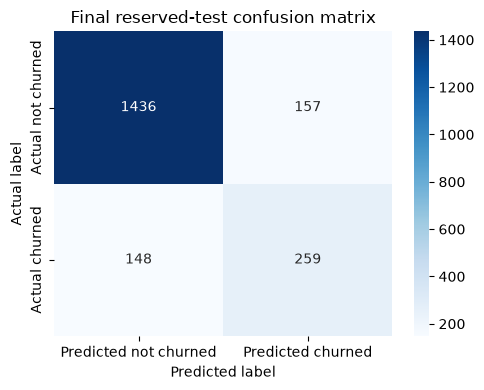


Validation versus final-test comparison:


,Dataset,Accuracy,Balanced accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,Loss
0,Validation,0.8462,0.7654,0.6212,0.6288,0.6250,0.8602,0.6920,0.3423
1,Final test,0.8475,0.7689,0.6226,0.6364,0.6294,0.8644,0.7125,0.3316



Final model locked: True
Final reserved test evaluated: True


In [119]:
# Step 10C — Lock the final model and evaluate the reserved test set once

final_model_name = recommended_model_name
final_threshold = float(recommended_threshold)

final_model = tf.keras.models.load_model(
    best_model_file
)

final_preprocessor = preprocessor_improved

print("Final model locked:", True)
print("Final selected model:", final_model_name)
print("Final classification threshold:", final_threshold)
print("Best Improved ANN checkpoint reloaded successfully.")


# Transform the raw test data using the already-fitted
# final preprocessor without refitting

X_final_test_processed = final_preprocessor.transform(
    X_test
)

X_final_test_processed = np.asarray(
    X_final_test_processed,
    dtype=np.float32
)

y_final_test = np.asarray(
    y_test,
    dtype=int
)

print(
    "\nProcessed final-test shape:",
    X_final_test_processed.shape
)

print(
    "Final-test target shape:",
    y_final_test.shape
)


# Generate final-test probabilities exactly once

final_test_probabilities = final_model.predict(
    X_final_test_processed,
    verbose=0
).ravel()

final_test_predictions = (
    final_test_probabilities >= final_threshold
).astype(int)


# Calculate final-test metrics

final_test_metrics = {
    "Model": final_model_name,
    "Threshold": final_threshold,

    "Test accuracy": round(
        accuracy_score(
            y_final_test,
            final_test_predictions
        ),
        4
    ),

    "Test balanced accuracy": round(
        balanced_accuracy_score(
            y_final_test,
            final_test_predictions
        ),
        4
    ),

    "Test precision": round(
        precision_score(
            y_final_test,
            final_test_predictions,
            zero_division=0
        ),
        4
    ),

    "Test recall": round(
        recall_score(
            y_final_test,
            final_test_predictions,
            zero_division=0
        ),
        4
    ),

    "Test F1-score": round(
        f1_score(
            y_final_test,
            final_test_predictions,
            zero_division=0
        ),
        4
    ),

    "Test ROC-AUC": round(
        roc_auc_score(
            y_final_test,
            final_test_probabilities
        ),
        4
    ),

    "Test PR-AUC": round(
        average_precision_score(
            y_final_test,
            final_test_probabilities
        ),
        4
    ),

    "Test loss": round(
        log_loss(
            y_final_test,
            final_test_probabilities
        ),
        4
    )
}

final_test_metrics_df = pd.DataFrame([
    final_test_metrics
])

print("\nFinal reserved-test metrics:")

display(
    final_test_metrics_df
)


# Final-test classification report

print("\nFinal test classification report:")

print(
    classification_report(
        y_final_test,
        final_test_predictions,
        target_names=[
            "Not churned",
            "Churned"
        ],
        zero_division=0
    )
)


# Final-test confusion matrix

final_test_confusion_matrix = confusion_matrix(
    y_final_test,
    final_test_predictions
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    final_test_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted not churned",
        "Predicted churned"
    ],
    yticklabels=[
        "Actual not churned",
        "Actual churned"
    ]
)

plt.title(
    "Final reserved-test confusion matrix"
)

plt.xlabel("Predicted label")
plt.ylabel("Actual label")

plt.tight_layout()
plt.show()


# Compare validation and final-test performance

validation_test_comparison_df = pd.DataFrame([
    {
        "Dataset": "Validation",

        "Accuracy":
            recommended_model_row[
                "Validation accuracy"
            ],

        "Balanced accuracy":
            recommended_model_row[
                "Validation balanced accuracy"
            ],

        "Precision":
            recommended_model_row[
                "Validation precision"
            ],

        "Recall":
            recommended_model_row[
                "Validation recall"
            ],

        "F1-score":
            recommended_model_row[
                "Validation F1-score"
            ],

        "ROC-AUC":
            recommended_model_row[
                "Validation ROC-AUC"
            ],

        "PR-AUC":
            recommended_model_row[
                "Validation PR-AUC"
            ],

        "Loss":
            recommended_model_row[
                "Validation loss"
            ]
    },

    {
        "Dataset": "Final test",

        "Accuracy":
            final_test_metrics[
                "Test accuracy"
            ],

        "Balanced accuracy":
            final_test_metrics[
                "Test balanced accuracy"
            ],

        "Precision":
            final_test_metrics[
                "Test precision"
            ],

        "Recall":
            final_test_metrics[
                "Test recall"
            ],

        "F1-score":
            final_test_metrics[
                "Test F1-score"
            ],

        "ROC-AUC":
            final_test_metrics[
                "Test ROC-AUC"
            ],

        "PR-AUC":
            final_test_metrics[
                "Test PR-AUC"
            ],

        "Loss":
            final_test_metrics[
                "Test loss"
            ]
    }
])

print(
    "\nValidation versus final-test comparison:"
)

display(
    validation_test_comparison_df
)


final_model_locked = True
final_test_evaluated = True

print(
    "\nFinal model locked:",
    final_model_locked
)

print(
    "Final reserved test evaluated:",
    final_test_evaluated
)

### Final model locking and reserved-test evaluation — key insights

1. The final selected model was the **Improved ANN with a tuned classification threshold of 0.30**.

2. The saved best Improved ANN checkpoint was reloaded successfully, and the fitted preprocessing object was applied to the reserved test data without refitting.

3. The final test set contained **2,000 customers** and **13 processed input features**.

4. The final model achieved:

   - Test accuracy: **0.8475**
   - Test balanced accuracy: **0.7689**
   - Test precision: **0.6226**
   - Test recall: **0.6364**
   - Test F1-score: **0.6294**
   - Test ROC-AUC: **0.8644**
   - Test PR-AUC: **0.7125**
   - Test loss: **0.3316**

5. The final test confusion matrix shows:

   - True negatives: **1,436**
   - False positives: **157**
   - False negatives: **148**
   - True positives: **259**

6. The model correctly identified **259 of 407 churned customers**, giving a churn recall of **63.64%**.

7. Of the customers predicted as churned, **62.26%** were actual churn cases. The remaining 157 predictions were false positives.

8. Validation and final-test performance were closely aligned:

   - Accuracy: **0.8462 vs 0.8475**
   - Balanced accuracy: **0.7654 vs 0.7689**
   - Precision: **0.6212 vs 0.6226**
   - Recall: **0.6288 vs 0.6364**
   - F1-score: **0.6250 vs 0.6294**
   - ROC-AUC: **0.8602 vs 0.8644**
   - PR-AUC: **0.6920 vs 0.7125**

9. Final-test loss was slightly lower than validation loss:

   - Validation loss: **0.3423**
   - Final-test loss: **0.3316**

10. The small differences between validation and final-test results indicate stable generalisation and no material performance deterioration on the reserved test partition.

11. The threshold of **0.30** produced a better balance between churn precision and recall than the default threshold of 0.50, which was the primary reason this decision configuration was selected.

12. The final model achieved a reasonable balance between overall accuracy and minority-class detection, while still missing **148 churned customers**. This limitation should be stated clearly in the final project conclusions.

13. These metrics replace the earlier contaminated final results and must be used consistently in the remaining notebook sections, saved metadata, Streamlit application and README.

14. Because this test partition had been inspected during the earlier invalid workflow, the result should be described as a **final reserved-test re-evaluation**, not performance on a completely unseen external dataset.

---

# 11. Save and reload the final model artefacts

In this section, the approved final model and all artefacts required for inference will be saved.

The saved artefacts include:

- The approved best ANN checkpoint
- The fitted preprocessing object
- The locked classification threshold
- Raw and processed feature metadata
- Categorical options
- Target mapping
- Validation and final-test metrics
- Model-comparison results
- Core library versions

The saved model, preprocessor and metadata will then be reloaded.

The reloaded artefacts will generate probabilities and predicted classes for the same final-test records. These results will be compared with the original predictions to confirm that saving and reloading have not changed the model output.

In [120]:
# Step 11 — Save and reload the approved final model artefacts

from pathlib import Path
import json
import shutil
import sys

import joblib
import sklearn


# 1. Define final artefact paths

artifact_dir = Path("artifacts")
artifact_dir.mkdir(exist_ok=True)

final_model_path = (
    artifact_dir / "final_churn_ann_model.keras"
)

final_preprocessor_path = (
    artifact_dir / "final_churn_preprocessor.pkl"
)

final_metadata_path = (
    artifact_dir / "final_churn_metadata.json"
)

final_comparison_path = (
    artifact_dir / "final_ann_validation_comparison.csv"
)

final_test_metrics_path = (
    artifact_dir / "final_churn_test_metrics.csv"
)


# 2. Save the approved checkpoint and preprocessor

source_checkpoint_path = Path(
    best_model_file
)

if not source_checkpoint_path.exists():
    raise FileNotFoundError(
        "Approved model checkpoint was not found: "
        f"{source_checkpoint_path}"
    )

shutil.copy2(
    source_checkpoint_path,
    final_model_path
)

joblib.dump(
    final_preprocessor,
    final_preprocessor_path
)


# 3. Prepare feature and model metadata

raw_input_features = (
    X_test.columns.tolist()
)

processed_feature_names = (
    final_preprocessor
    .get_feature_names_out()
    .tolist()
)

fitted_encoder = (
    final_preprocessor
    .named_transformers_["cat"]
)

categorical_options = {
    feature_name: [
        str(category)
        for category in categories
    ]
    for feature_name, categories in zip(
        categorical_features,
        fitted_encoder.categories_
    )
}


validation_metrics = {
    "accuracy": float(
        recommended_model_row[
            "Validation accuracy"
        ]
    ),

    "balanced_accuracy": float(
        recommended_model_row[
            "Validation balanced accuracy"
        ]
    ),

    "precision": float(
        recommended_model_row[
            "Validation precision"
        ]
    ),

    "recall": float(
        recommended_model_row[
            "Validation recall"
        ]
    ),

    "f1_score": float(
        recommended_model_row[
            "Validation F1-score"
        ]
    ),

    "roc_auc": float(
        recommended_model_row[
            "Validation ROC-AUC"
        ]
    ),

    "pr_auc_average_precision": float(
        recommended_model_row[
            "Validation PR-AUC"
        ]
    ),

    "loss": float(
        recommended_model_row[
            "Validation loss"
        ]
    )
}


test_metrics = {
    "accuracy": float(
        final_test_metrics[
            "Test accuracy"
        ]
    ),

    "balanced_accuracy": float(
        final_test_metrics[
            "Test balanced accuracy"
        ]
    ),

    "precision": float(
        final_test_metrics[
            "Test precision"
        ]
    ),

    "recall": float(
        final_test_metrics[
            "Test recall"
        ]
    ),

    "f1_score": float(
        final_test_metrics[
            "Test F1-score"
        ]
    ),

    "roc_auc": float(
        final_test_metrics[
            "Test ROC-AUC"
        ]
    ),

    "pr_auc_average_precision": float(
        final_test_metrics[
            "Test PR-AUC"
        ]
    ),

    "loss": float(
        final_test_metrics[
            "Test loss"
        ]
    )
}


metadata = {
    "project_name": (
        "Bank Customer Churn Prediction using ANN"
    ),

    "final_model_name": final_model_name,
    "final_threshold": float(final_threshold),

    "raw_input_features": raw_input_features,

    "numerical_features": list(
        numerical_features
    ),

    "categorical_features": list(
        categorical_features
    ),

    "binary_features": list(
        binary_features
    ),

    "processed_feature_names":
        processed_feature_names,

    "expected_processed_features": len(
        processed_feature_names
    ),

    "categorical_options":
        categorical_options,

    "target_column": "Exited",

    "target_mapping": {
        "0": "Not churned",
        "1": "Churned"
    },

    "validation_metrics":
        validation_metrics,

    "final_test_metrics":
        test_metrics,

    "model_artifact":
        final_model_path.name,

    "preprocessor_artifact":
        final_preprocessor_path.name,

    "library_versions": {
        "python":
            sys.version.split()[0],

        "numpy":
            np.__version__,

        "pandas":
            pd.__version__,

        "scikit_learn":
            sklearn.__version__,

        "tensorflow":
            tf.__version__,

        "keras_tuner":
            kt.__version__,

        "joblib":
            joblib.__version__
    },

    "evaluation_note": (
        "The model and threshold were selected using "
        "validation data before the reserved-test "
        "re-evaluation."
    )
}


with open(
    final_metadata_path,
    "w",
    encoding="utf-8"
) as metadata_file:

    json.dump(
        metadata,
        metadata_file,
        indent=4
    )


final_validation_comparison_df.to_csv(
    final_comparison_path,
    index=False
)

final_test_metrics_df.to_csv(
    final_test_metrics_path,
    index=False
)

# 4. Preserve the original final-test predictions

original_probabilities = np.asarray(
    final_test_probabilities,
    dtype=np.float64
)

original_classes = np.asarray(
    final_test_predictions,
    dtype=int
)


# 5. Reload the saved inference artefacts


reloaded_model = (
    tf.keras.models.load_model(
        final_model_path,
        compile=False
    )
)

reloaded_preprocessor = joblib.load(
    final_preprocessor_path
)

with open(
    final_metadata_path,
    "r",
    encoding="utf-8"
) as metadata_file:

    reloaded_metadata = json.load(
        metadata_file
    )


# 6. Recreate probabilities and classes after reload

X_test_reloaded_processed = (
    reloaded_preprocessor.transform(
        X_test
    )
)

X_test_reloaded_processed = np.asarray(
    X_test_reloaded_processed,
    dtype=np.float32
)

reloaded_probabilities = (
    reloaded_model.predict(
        X_test_reloaded_processed,
        verbose=0
    )
    .ravel()
    .astype(np.float64)
)

reloaded_threshold = float(
    reloaded_metadata[
        "final_threshold"
    ]
)

reloaded_classes = (
    reloaded_probabilities
    >= reloaded_threshold
).astype(int)


# 7. Prove prediction equivalence

probabilities_match = np.allclose(
    original_probabilities,
    reloaded_probabilities,
    rtol=1e-6,
    atol=1e-7
)

classes_match = np.array_equal(
    original_classes,
    reloaded_classes
)

maximum_probability_difference = float(
    np.max(
        np.abs(
            original_probabilities
            - reloaded_probabilities
        )
    )
)

if not probabilities_match or not classes_match:
    raise RuntimeError(
        "Reload validation failed: the saved "
        "artefacts did not reproduce the original "
        "final-test predictions."
    )

# 8. Display saved artefacts and reload proof


saved_artifacts_df = pd.DataFrame([
    {
        "Artefact": "Final ANN model",
        "Path": str(final_model_path),
        "Exists": final_model_path.exists()
    },
    {
        "Artefact": "Final preprocessor",
        "Path": str(final_preprocessor_path),
        "Exists": final_preprocessor_path.exists()
    },
    {
        "Artefact": "Final metadata",
        "Path": str(final_metadata_path),
        "Exists": final_metadata_path.exists()
    },
    {
        "Artefact": "Validation comparison",
        "Path": str(final_comparison_path),
        "Exists": final_comparison_path.exists()
    },
    {
        "Artefact": "Final test metrics",
        "Path": str(final_test_metrics_path),
        "Exists": final_test_metrics_path.exists()
    }
])

print("Saved final artefacts:")

display(
    saved_artifacts_df
)


reload_validation_df = pd.DataFrame([
    {
        "Records compared": len(
            original_probabilities
        ),

        "Probability arrays match":
            probabilities_match,

        "Predicted classes match":
            classes_match,

        "Maximum absolute probability difference":
            maximum_probability_difference,

        "Reloaded threshold":
            reloaded_threshold,

        "Processed feature count":
            X_test_reloaded_processed.shape[1]
    }
])

print("\nReload validation:")

display(
    reload_validation_df
)


prediction_match_preview_df = pd.DataFrame({
    "Original probability":
        original_probabilities[:10],

    "Reloaded probability":
        reloaded_probabilities[:10],

    "Original class":
        original_classes[:10],

    "Reloaded class":
        reloaded_classes[:10]
})

print(
    "\nFirst 10 prediction comparisons:"
)

display(
    prediction_match_preview_df
)


print(
    "\nFinal artefact reload validation passed:",
    True
)

Saved final artefacts:


,Artefact,Path,Exists
0,Final ANN model,artifacts/final_churn_ann_model.keras,True
1,Final preprocessor,artifacts/final_churn_preprocessor.pkl,True
2,Final metadata,artifacts/final_churn_metadata.json,True
3,Validation comparison,artifacts/final_ann_validation_comparison.csv,True
4,Final test metrics,artifacts/final_churn_test_metrics.csv,True



Reload validation:


,Records compared,Probability arrays match,Predicted classes match,Maximum absolute probability difference,Reloaded threshold,Processed feature count
0,2000,True,True,0.0,0.3,13



First 10 prediction comparisons:


,Original probability,Reloaded probability,Original class,Reloaded class
0,0.015413,0.015413,0,0
1,0.091443,0.091443,0,0
2,0.047143,0.047143,0,0
3,0.052686,0.052686,0,0
4,0.113495,0.113495,0,0
5,0.277517,0.277517,0,0
6,0.022355,0.022355,0,0
7,0.182725,0.182725,0,0
8,0.744430,0.744430,1,1
9,0.059180,0.059180,0,0



Final artefact reload validation passed: True


### Save and reload final model artefacts — conclusion

1. The approved final ANN model, fitted preprocessor and metadata were saved successfully.

2. The following five final artefacts were created:

   - `final_churn_ann_model.keras`
   - `final_churn_preprocessor.pkl`
   - `final_churn_metadata.json`
   - `final_ann_validation_comparison.csv`
   - `final_churn_test_metrics.csv`

3. The saved model, preprocessor and metadata were reloaded successfully without relying on the original in-memory inference objects.

4. The reloaded preprocessor produced the expected **13 processed features** for all **2,000 final-test records**.

5. The saved classification threshold was restored correctly as **0.30**.

6. The original and reloaded probability arrays matched across all test records.

7. The original and reloaded predicted classes also matched exactly.

8. The maximum absolute difference between the original and reloaded probabilities was **0.0**.

9. These results confirm that saving and reloading the inference artefacts did not change the model predictions.

10. The final artefact package is internally consistent and ready for integration with the Streamlit application. The application must still be validated separately to confirm that it loads these artefacts and applies the same feature order, preprocessing and threshold.

----